In [2]:
import numpy as np
import pandas as pd
import clean_data
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer, KNNImputer, MissingIndicator
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder, MinMaxScaler, PowerTransformer, OrdinalEncoder
from sklearn.model_selection import train_test_split

In [3]:
import dagshub
dagshub.init(repo_owner='KaustukJaiswal', repo_name='food-delivery-time-prediction', mlflow=True)

Accessing as KaustukJaiswal

Initialized MLflow to track repo "KaustukJaiswal/food-delivery-time-prediction"

Repository KaustukJaiswal/food-delivery-time-prediction initialized!

In [4]:
import mlflow

print(mlflow.get_tracking_uri())

https://dagshub.com/KaustukJaiswal/food-delivery-time-prediction.mlflow


In [5]:

from sklearn import set_config

set_config(transform_output="pandas")

In [6]:

# load the data
df=pd.read_csv("../data/raw/swiggy.csv")
clean_data.perform_data_cleaning(df)

In [7]:
df=pd.read_csv("../data/raw/cleaned_data.csv")

In [8]:
df

,rider_id,age,ratings,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude,order_date,weather,traffic,...,city_name,order_day,order_month,order_day_of_week,is_weekend,pickup_time_minutes,order_time_hour,order_time_of_day,distance,distance_type
0,INDORES13DEL02,37.0,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,Sunny,high,...,INDO,19,3,saturday,1,15.0,11.0,morning,3.025149,short
1,BANGRES18DEL02,34.0,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,Stormy,jam,...,BANG,25,3,friday,0,5.0,19.0,evening,20.183530,very_long
2,BANGRES19DEL01,23.0,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,Sandstorms,low,...,BANG,19,3,saturday,1,15.0,8.0,morning,1.552758,short
3,COIMBRES13DEL02,38.0,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,Sunny,medium,...,COIMB,5,4,tuesday,0,10.0,18.0,evening,7.790401,medium
4,CHENRES12DEL01,32.0,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,Cloudy,high,...,CHEN,26,3,saturday,1,15.0,13.0,afternoon,6.210138,medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45497,JAPRES04DEL01,30.0,4.8,26.902328,75.794257,26.912328,75.804257,2022-03-24,Windy,high,...,JAP,24,3,thursday,0,10.0,11.0,morning,1.489846,short
45498,AGRRES16DEL01,21.0,4.6,NaN,NaN,NaN,NaN,2022-02-16,Windy,jam,...,AGR,16,2,wednesday,0,15.0,19.0,evening,NaN,NaN
45499,CHENRES08DEL03,30.0,4.9,13.022394,80.242439,13.052394,80.272439,2022-03-11,Cloudy,low,...,CHEN,11,3,friday,0,15.0,23.0,night,4.657195,short
45500,COIMBRES11DEL01,20.0,4.7,11.001753,76.986241,11.041753,77.026241,2022-03-07,Cloudy,high,...,COIMB,7,3,monday,0,5.0,13.0,afternoon,6.232393,medium


In [9]:
df.columns

Index(['rider_id', 'age', 'ratings', 'restaurant_latitude',
       'restaurant_longitude', 'delivery_latitude', 'delivery_longitude',
       'order_date', 'weather', 'traffic', 'vehicle_condition',
       'type_of_order', 'type_of_vehicle', 'multiple_deliveries', 'festival',
       'city_type', 'time_taken', 'city_name', 'order_day', 'order_month',
       'order_day_of_week', 'is_weekend', 'pickup_time_minutes',
       'order_time_hour', 'order_time_of_day', 'distance', 'distance_type'],
      dtype='object')

In [10]:
columns_to_drop =  ['rider_id',
                    'restaurant_latitude',
                    'restaurant_longitude',
                    'delivery_latitude',
                    'delivery_longitude',
                    'order_date',
                    "order_time_hour",
                    "order_day",
                    "city_name",
                    "order_day_of_week",
                    "order_month"]

df.drop(columns=columns_to_drop, inplace=True)


In [11]:
df

,age,ratings,weather,traffic,vehicle_condition,type_of_order,type_of_vehicle,multiple_deliveries,festival,city_type,time_taken,is_weekend,pickup_time_minutes,order_time_of_day,distance,distance_type
0,37.0,4.9,Sunny,high,2,snack,motorcycle,0.0,no,urban,24,1,15.0,morning,3.025149,short
1,34.0,4.5,Stormy,jam,2,snack,scooter,1.0,no,metropolitian,33,0,5.0,evening,20.183530,very_long
2,23.0,4.4,Sandstorms,low,0,drinks,motorcycle,1.0,no,urban,26,1,15.0,morning,1.552758,short
3,38.0,4.7,Sunny,medium,0,buffet,motorcycle,1.0,no,metropolitian,21,0,10.0,evening,7.790401,medium
4,32.0,4.6,Cloudy,high,1,snack,scooter,1.0,no,metropolitian,30,1,15.0,afternoon,6.210138,medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45497,30.0,4.8,Windy,high,1,meal,motorcycle,0.0,no,metropolitian,32,0,10.0,morning,1.489846,short
45498,21.0,4.6,Windy,jam,0,buffet,motorcycle,1.0,no,metropolitian,36,0,15.0,evening,NaN,NaN
45499,30.0,4.9,Cloudy,low,1,drinks,scooter,0.0,no,metropolitian,16,0,15.0,night,4.657195,short
45500,20.0,4.7,Cloudy,high,0,snack,motorcycle,1.0,no,metropolitian,26,0,5.0,afternoon,6.232393,medium


In [12]:

# check for missing values

df.isna().sum()

age                    1854
ratings                1908
weather                 525
traffic                 510
vehicle_condition         0
type_of_order             0
type_of_vehicle           0
multiple_deliveries     993
festival                228
city_type              1198
time_taken                0
is_weekend                0
pickup_time_minutes    1640
order_time_of_day      2070
distance               3630
distance_type          3630
dtype: int64

In [13]:
df.duplicated().sum()

np.int64(0)

<Axes: >

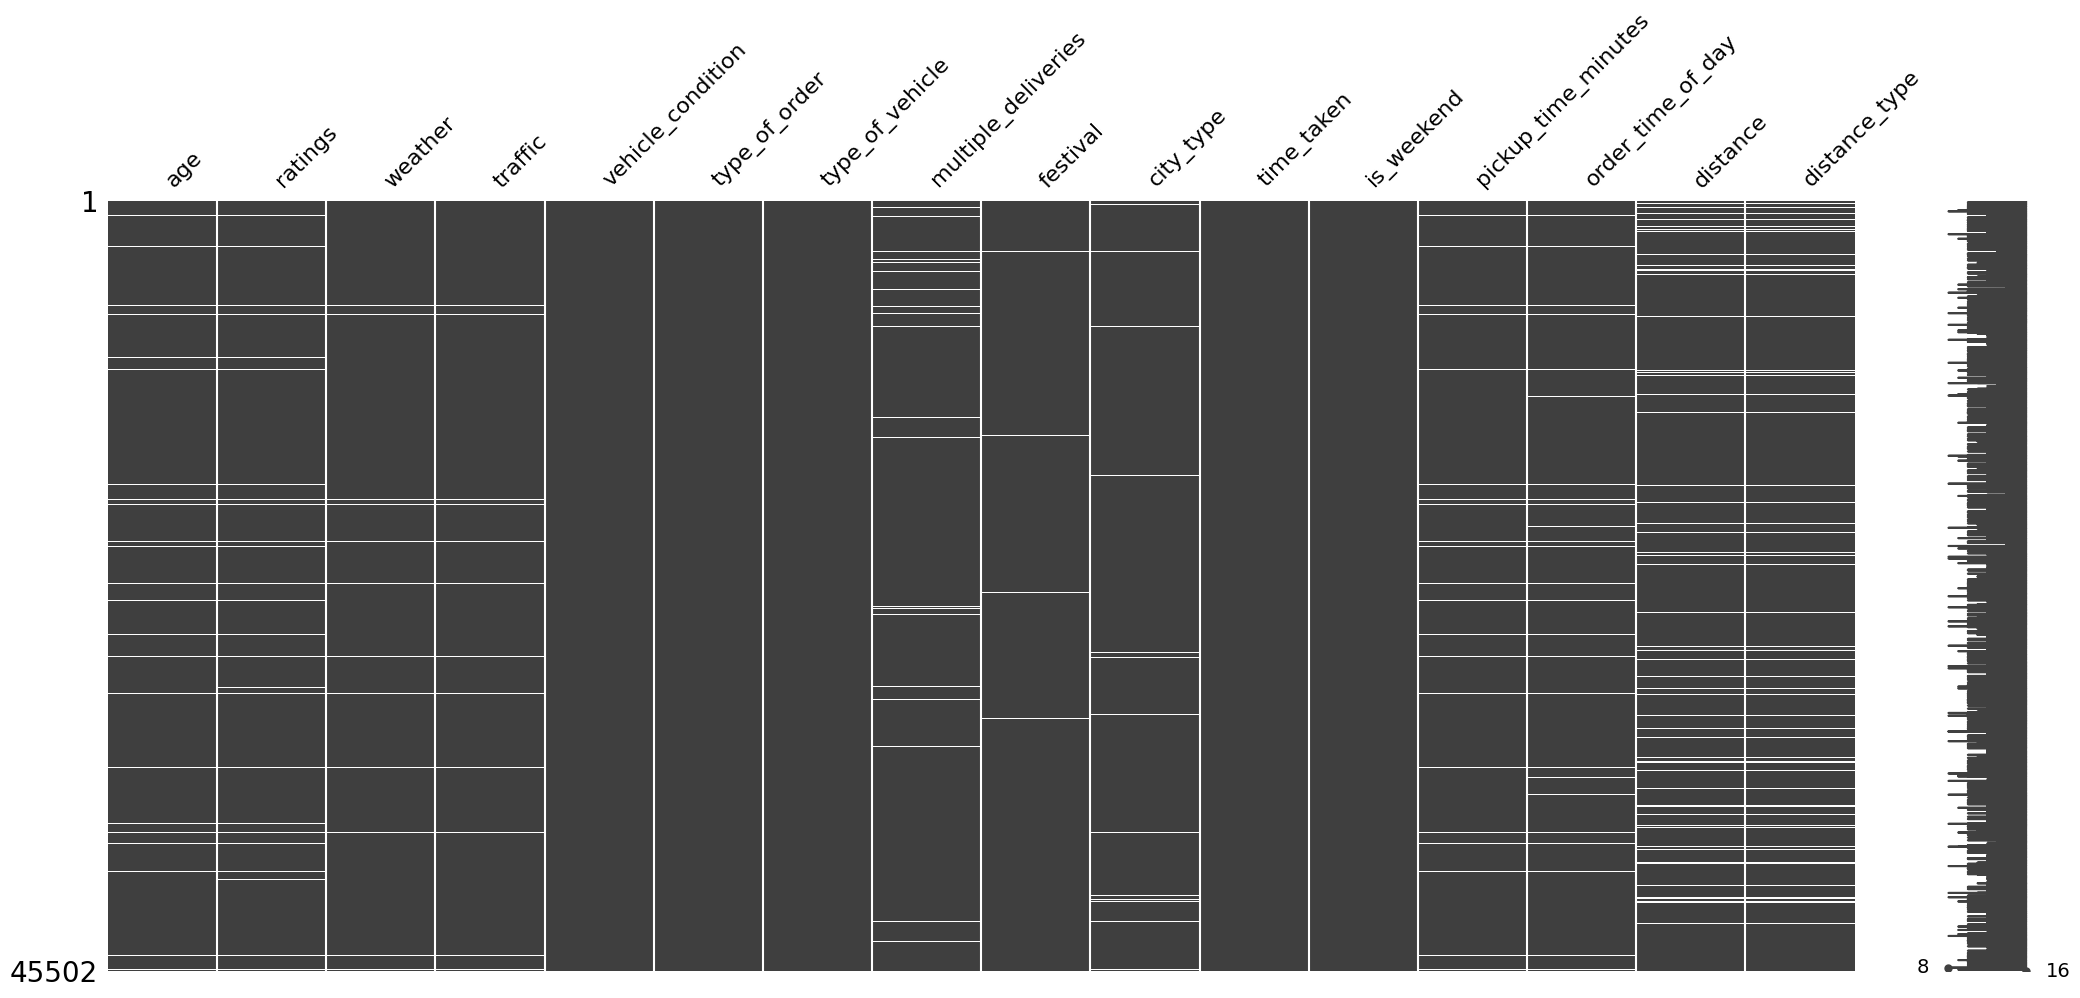

In [14]:
import missingno as msno

msno.matrix(df)

In [15]:
#columns that have missing values
(
    df.isna().any(axis=0).loc[lambda x:x].index
)

Index(['age', 'ratings', 'weather', 'traffic', 'multiple_deliveries',
       'festival', 'city_type', 'pickup_time_minutes', 'order_time_of_day',
       'distance', 'distance_type'],
      dtype='object')

In [16]:
#Droping missing values

In [17]:
import mlflow

In [18]:
mlflow.get_tracking_uri()

'https://dagshub.com/KaustukJaiswal/food-delivery-time-prediction.mlflow'

In [19]:
mlflow.set_tracking_uri('https://dagshub.com/KaustukJaiswal/food-delivery-time-prediction.mlflow')

In [20]:
mlflow.set_experiment("Experiment 1- Random Forest- Keeping VS dropped missing values")

<Experiment: artifact_location='mlflow-artifacts:/0e56cfcd606546caa69809b8caa4807c', creation_time=1783741698712, experiment_id='2', last_update_time=1783741698712, lifecycle_stage='active', name='Experiment 1- Random Forest- Keeping VS dropped missing values', tags={}>

In [21]:
temp_df=df.copy().dropna()

In [22]:
X=temp_df.drop(columns='time_taken')
y=temp_df['time_taken']

In [23]:
# train test split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [24]:
X_train.shape,X_test.shape

((30156, 15), (7539, 15))

In [25]:
X_train.isna().sum()

age                    0
ratings                0
weather                0
traffic                0
vehicle_condition      0
type_of_order          0
type_of_vehicle        0
multiple_deliveries    0
festival               0
city_type              0
is_weekend             0
pickup_time_minutes    0
order_time_of_day      0
distance               0
distance_type          0
dtype: int64

In [26]:
num_cols = ["age","ratings","pickup_time_minutes","distance"]

nominal_cat_cols = ['weather',
                    'type_of_order',
                    'type_of_vehicle',
                    "festival",
                    "city_type",
                    "is_weekend",
                    "order_time_of_day"]

ordinal_cat_cols = ["traffic","distance_type"]

# generate order for ordinal encoding

traffic_order = ["low","medium","high","jam"]

distance_type_order = ["short","medium","long","very_long"]

In [27]:
# build a preprocessor

preprocessor = ColumnTransformer(transformers=[
    ("scale", MinMaxScaler(), num_cols),
    ("nominal_encode", OneHotEncoder(drop="first",handle_unknown="ignore",
                                     sparse_output=False), nominal_cat_cols),
    ("ordinal_encode", OrdinalEncoder(categories=[traffic_order,distance_type_order],
                                      encoded_missing_value=-999,
                                      handle_unknown="use_encoded_value",
                                      unknown_value=-1), ordinal_cat_cols)
],remainder="passthrough",n_jobs=-1,force_int_remainder_cols=False,verbose_feature_names_out=False)

preprocessor.set_output(transform="pandas")

,transformers,"[('scale', ...), ('nominal_encode', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,-1
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False
,force_int_remainder_cols,False
,feature_range,"(0, ...)"
,copy,True
,clip,False


In [28]:
# transform the data

X_train_trans = preprocessor.fit_transform(X_train)
X_test_trans = preprocessor.transform(X_test)

X_train_trans

C:\Users\Lenovo\AppData\Roaming\Python\Python313\site-packages\sklearn\compose\_column_transformer.py:975: FutureWarning: The parameter `force_int_remainder_cols` is deprecated and will be removed in 1.9. It has no effect. Leave it to its default value to avoid this warning.
  warnings.warn(


,age,ratings,pickup_time_minutes,distance,weather_Fog,weather_Sandstorms,weather_Stormy,weather_Sunny,weather_Windy,type_of_order_drinks,...,city_type_semi-urban,city_type_urban,is_weekend_1,order_time_of_day_evening,order_time_of_day_morning,order_time_of_day_night,traffic,distance_type,vehicle_condition,multiple_deliveries
8708,0.473684,0.56,1.0,0.404165,0.0,0.0,0.0,1.0,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,1.0,3.0,1.0,0,2.0
25198,1.000000,0.76,0.0,0.154044,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0,1.0
34049,0.473684,0.80,0.5,0.002461,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0,1,0.0
25987,1.000000,0.92,1.0,0.460411,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0,1.0
37121,0.526316,0.76,0.5,0.243676,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20239,0.578947,0.92,0.5,0.451895,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,3.0,2.0,0,0.0
7590,0.052632,1.00,1.0,0.612270,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,1.0,2.0,1,1.0
13610,0.526316,0.92,0.0,0.322877,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1,0.0
1045,0.947368,0.96,0.5,0.004486,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0,1.0


In [29]:
# transform target column

pt = PowerTransformer()

y_train_pt = pt.fit_transform(y_train.values.reshape(-1,1))
y_test_pt = pt.transform(y_test.values.reshape(-1,1))

In [30]:
pt.lambdas_

array([0.32446096])

In [31]:
y_train_pt.values

array([[ 2.02867161],
       [ 0.55453913],
       [-2.0242672 ],
       ...,
       [-1.35093653],
       [ 0.04711066],
       [ 0.2571302 ]], shape=(30156, 1))

In [32]:
from sklearn.ensemble import RandomForestRegressor
rf=RandomForestRegressor()
rf.fit(X_train_trans,y_train_pt)

C:\Users\Lenovo\AppData\Roaming\Python\Python313\site-packages\sklearn\base.py:1363: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [33]:
# get the predictions
y_pred_train = rf.predict(X_train_trans)
y_pred_test = rf.predict(X_test_trans)

In [34]:
#get original prediction values
y_pred_train_org=pt.inverse_transform(y_pred_train.reshape(-1,1))
y_pred_test_org = pt.inverse_transform(y_pred_test.reshape(-1,1))

In [35]:
from sklearn.metrics import mean_absolute_error, r2_score

print(f"The train error is {mean_absolute_error(y_train,y_pred_train_org):.2f} minutes")
print(f"The test error is {mean_absolute_error(y_test,y_pred_test_org):.2f} minutes")

The train error is 1.16 minutes
The test error is 3.09 minutes


In [36]:
print(f"The train r2 score is {r2_score(y_train,y_pred_train_org):.2f}")
print(f"The test r2 score is {r2_score(y_test,y_pred_test_org):.2f}")

The train r2 score is 0.98
The test r2 score is 0.83


<Axes: >

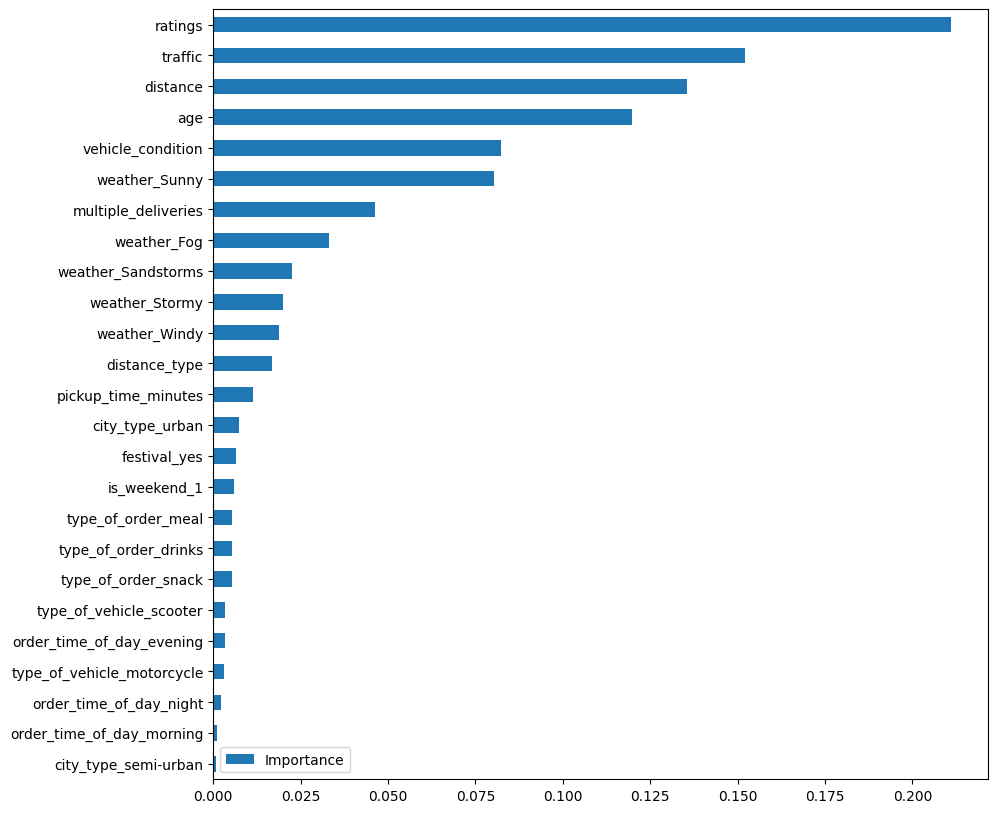

In [37]:
pd.DataFrame(rf.feature_importances_,index=X_test_trans.columns,columns=['Importance']).sort_values(by='Importance').plot(kind='barh',figsize=(10,10))

In [38]:
with mlflow.start_run(run_name="Droped Missing Values"):
    mlflow.log_param("experiment_type","Droped Missing Values")
    mlflow.log_params(rf.get_params())
    mlflow.log_metric("training_error",mean_absolute_error(y_train,y_pred_train_org))
    mlflow.log_metric("test_error",mean_absolute_error(y_test,y_pred_test_org))
    mlflow.log_metric("training_r2",r2_score(y_train,y_pred_train_org))
    mlflow.log_metric("test_r2",r2_score(y_test,y_pred_test_org))
    

🏃 View run Droped Missing Values at: https://dagshub.com/KaustukJaiswal/food-delivery-time-prediction.mlflow/#/experiments/2/runs/589ce631d68d4a6fb4ca0d1c76a51026
🧪 View experiment at: https://dagshub.com/KaustukJaiswal/food-delivery-time-prediction.mlflow/#/experiments/2


In [39]:
from sklearn.feature_selection import RFECV

rfecv=RFECV(
    estimator=rf,
    step=5,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=2
)

##### Imputing missing values

In [40]:
temp_df = df.copy()

In [41]:
# split into X and y

X = temp_df.drop(columns='time_taken')
y = temp_df['time_taken']

In [42]:
# train test split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [43]:
X_train.shape,X_test.shape

((36401, 15), (9101, 15))

In [44]:
X_train.isna().sum()

age                    1470
ratings                1510
weather                 421
traffic                 407
vehicle_condition         0
type_of_order             0
type_of_vehicle           0
multiple_deliveries     795
festival                188
city_type               968
is_weekend                0
pickup_time_minutes    1298
order_time_of_day      1646
distance               2931
distance_type          2931
dtype: int64

In [45]:
pt = PowerTransformer()

y_train_pt = pt.fit_transform(y_train.values.reshape(-1,1))
y_test_pt = pt.transform(y_test.values.reshape(-1,1))

In [46]:
missing_cols=(
    X_train.isna().any(axis=0).loc[lambda x:x].index
)

In [47]:
(X_train.isna().any(axis=1).sum()/X_train.shape[0])*100

np.float64(17.2660091755721)

In [48]:
nominal_cat_cols

['weather',
 'type_of_order',
 'type_of_vehicle',
 'festival',
 'city_type',
 'is_weekend',
 'order_time_of_day']

In [49]:
ordinal_cat_cols

['traffic', 'distance_type']

In [50]:
num_cols

['age', 'ratings', 'pickup_time_minutes', 'distance']

In [51]:
# features to fill values with mode

features_to_fill_mode = ['multiple_deliveries','festival','city_type']
features_to_fill_missing = [col for col in nominal_cat_cols if col not in features_to_fill_mode]

features_to_fill_missing

['weather',
 'type_of_order',
 'type_of_vehicle',
 'is_weekend',
 'order_time_of_day']

In [52]:
# simple imputer to fill categorical vars with mode

simple_imputer = ColumnTransformer(transformers=[
    ("mode_imputer",SimpleImputer(strategy="most_frequent"),features_to_fill_mode),
    ("missing_imputer",SimpleImputer(strategy="constant",fill_value="missing"),features_to_fill_missing)
],remainder="passthrough",n_jobs=-1,force_int_remainder_cols=False,verbose_feature_names_out=False)

simple_imputer

,transformers,"[('mode_imputer', ...), ('missing_imputer', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,-1
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False
,force_int_remainder_cols,False
,missing_values,nan
,strategy,'most_frequent'
,fill_value,None


In [53]:
simple_imputer.fit_transform(X_train)

C:\Users\Lenovo\AppData\Roaming\Python\Python313\site-packages\sklearn\compose\_column_transformer.py:975: FutureWarning: The parameter `force_int_remainder_cols` is deprecated and will be removed in 1.9. It has no effect. Leave it to its default value to avoid this warning.
  warnings.warn(


,multiple_deliveries,festival,city_type,weather,type_of_order,type_of_vehicle,is_weekend,order_time_of_day,age,ratings,traffic,vehicle_condition,pickup_time_minutes,distance,distance_type
11029,1.0,no,metropolitian,Windy,snack,electric_scooter,0,evening,26.0,4.7,jam,2,10.0,9.177684,medium
15665,1.0,no,metropolitian,Windy,drinks,motorcycle,0,afternoon,21.0,4.9,medium,2,5.0,6.081536,medium
14475,1.0,no,metropolitian,Stormy,meal,scooter,1,missing,NaN,NaN,low,2,NaN,1.554563,short
29199,1.0,no,metropolitian,Windy,buffet,motorcycle,0,evening,32.0,4.7,medium,0,15.0,20.852271,very_long
22514,0.0,no,urban,Sandstorms,meal,scooter,0,night,34.0,4.9,jam,1,5.0,9.056096,medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11284,0.0,no,metropolitian,Sandstorms,meal,scooter,0,evening,29.0,4.7,jam,2,5.0,12.464367,long
44732,0.0,no,urban,Cloudy,buffet,motorcycle,0,morning,36.0,4.8,low,0,10.0,1.520432,short
38158,0.0,no,metropolitian,Fog,buffet,scooter,0,evening,36.0,4.4,jam,1,10.0,NaN,NaN
860,1.0,no,metropolitian,Windy,meal,scooter,1,afternoon,25.0,4.9,medium,2,5.0,7.760938,medium


In [54]:
simple_imputer.fit_transform(X_train).isna().sum()

C:\Users\Lenovo\AppData\Roaming\Python\Python313\site-packages\sklearn\compose\_column_transformer.py:975: FutureWarning: The parameter `force_int_remainder_cols` is deprecated and will be removed in 1.9. It has no effect. Leave it to its default value to avoid this warning.
  warnings.warn(


multiple_deliveries       0
festival                  0
city_type                 0
weather                   0
type_of_order             0
type_of_vehicle           0
is_weekend                0
order_time_of_day         0
age                    1470
ratings                1510
traffic                 407
vehicle_condition         0
pickup_time_minutes    1298
distance               2931
distance_type          2931
dtype: int64

In [55]:
# knn imputer

knn_imputer = KNNImputer(n_neighbors=5)

In [56]:
traffic_order,distance_type_order

(['low', 'medium', 'high', 'jam'], ['short', 'medium', 'long', 'very_long'])

In [57]:
# build a preprocessor

preprocessor = ColumnTransformer(transformers=[
    ("scale", MinMaxScaler(), num_cols),
    ("nominal_encode", OneHotEncoder(drop="first",handle_unknown="ignore",
                                     sparse_output=False), nominal_cat_cols),
    ("ordinal_encode", OrdinalEncoder(categories=[traffic_order,distance_type_order],
                                      encoded_missing_value=-999,
                                      handle_unknown="use_encoded_value",
                                      unknown_value=-1), ordinal_cat_cols)
],remainder="passthrough",n_jobs=-1,force_int_remainder_cols=False,verbose_feature_names_out=False)
preprocessor

,transformers,"[('scale', ...), ('nominal_encode', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,-1
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False
,force_int_remainder_cols,False
,feature_range,"(0, ...)"
,copy,True
,clip,False


In [58]:
preprocessor.fit_transform(X_train)

C:\Users\Lenovo\AppData\Roaming\Python\Python313\site-packages\sklearn\compose\_column_transformer.py:975: FutureWarning: The parameter `force_int_remainder_cols` is deprecated and will be removed in 1.9. It has no effect. Leave it to its default value to avoid this warning.
  warnings.warn(


,age,ratings,pickup_time_minutes,distance,weather_Fog,weather_Sandstorms,weather_Stormy,weather_Sunny,weather_Windy,weather_nan,...,city_type_nan,is_weekend_1,order_time_of_day_evening,order_time_of_day_morning,order_time_of_day_night,order_time_of_day_nan,traffic,distance_type,vehicle_condition,multiple_deliveries
11029,0.315789,0.88,0.5,0.395429,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,3.0,1.0,2,1.0
15665,0.052632,0.96,0.0,0.236688,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,2,1.0
14475,NaN,NaN,NaN,0.004588,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,2,1.0
29199,0.631579,0.88,1.0,0.993990,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,3.0,0,1.0
22514,0.736842,0.96,0.0,0.389195,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,3.0,1.0,1,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11284,0.473684,0.88,0.0,0.563939,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,3.0,2.0,2,0.0
44732,0.842105,0.92,0.5,0.002839,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0,0.0
38158,0.842105,0.76,0.5,NaN,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,3.0,-1.0,1,0.0
860,0.263158,0.96,0.0,0.322792,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,2,1.0


In [59]:
preprocessor.fit_transform(X_train).isna().sum().loc[lambda x:x>0]

C:\Users\Lenovo\AppData\Roaming\Python\Python313\site-packages\sklearn\compose\_column_transformer.py:975: FutureWarning: The parameter `force_int_remainder_cols` is deprecated and will be removed in 1.9. It has no effect. Leave it to its default value to avoid this warning.
  warnings.warn(


age                    1470
ratings                1510
pickup_time_minutes    1298
distance               2931
multiple_deliveries     795
dtype: int64

In [60]:
preprocessing_pipeline = Pipeline(steps=[
                                ("simple_imputer",simple_imputer),
                                ("preprocess",preprocessor),
                                ("knn_imputer",knn_imputer)
                            ])
preprocessing_pipeline

,steps,"[('simple_imputer', ...), ('preprocess', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('mode_imputer', ...), ('missing_imputer', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,-1
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False


In [61]:
model_pipeline=Pipeline(steps=[('preprocessing',preprocessing_pipeline),
                               ("model",rf)
                               ])
model_pipeline

,steps,"[('preprocessing', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,steps,"[('simple_imputer', ...), ('preprocess', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('mode_imputer', ...), ('missing_imputer', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3


In [62]:
model_pipeline.fit(X_train,y_train_pt.values.ravel())

C:\Users\Lenovo\AppData\Roaming\Python\Python313\site-packages\sklearn\compose\_column_transformer.py:975: FutureWarning: The parameter `force_int_remainder_cols` is deprecated and will be removed in 1.9. It has no effect. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\Lenovo\AppData\Roaming\Python\Python313\site-packages\sklearn\compose\_column_transformer.py:975: FutureWarning: The parameter `force_int_remainder_cols` is deprecated and will be removed in 1.9. It has no effect. Leave it to its default value to avoid this warning.
  warnings.warn(


,steps,"[('preprocessing', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,steps,"[('simple_imputer', ...), ('preprocess', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('mode_imputer', ...), ('missing_imputer', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3


In [63]:
# predictions
y_pred_train = model_pipeline.predict(X_train)
y_pred_test = model_pipeline.predict(X_test)

In [64]:
y_pred_train_org = pt.inverse_transform(y_pred_train.reshape(-1,1))
y_pred_test_org = pt.inverse_transform(y_pred_test.reshape(-1,1))

In [65]:
from sklearn.metrics import mean_absolute_error, r2_score

print(f"The train error is {mean_absolute_error(y_train,y_pred_train_org):.2f} minutes")
print(f"The test error is {mean_absolute_error(y_test,y_pred_test_org):.2f} minutes")
     

The train error is 1.22 minutes
The test error is 3.30 minutes


In [66]:
print(f"The train r2 score is {r2_score(y_train,y_pred_train_org):.2f}")
print(f"The test r2 score is {r2_score(y_test,y_pred_test_org):.2f}")

The train r2 score is 0.97
The test r2 score is 0.80


In [67]:
# log experiment

with mlflow.start_run(run_name="Impute Missing Values"):
    mlflow.log_param("experiment_type","Impute Missing Values")
    mlflow.log_params(rf.get_params())
    mlflow.log_metric("training_error",mean_absolute_error(y_train,y_pred_train_org))
    mlflow.log_metric("test_error",mean_absolute_error(y_test,y_pred_test_org))
    mlflow.log_metric("training_r2",r2_score(y_train,y_pred_train_org))
    mlflow.log_metric("test_r2",r2_score(y_test,y_pred_test_org))

🏃 View run Impute Missing Values at: https://dagshub.com/KaustukJaiswal/food-delivery-time-prediction.mlflow/#/experiments/2/runs/1a6c8dece37641e3ac869f78f5041e83
🧪 View experiment at: https://dagshub.com/KaustukJaiswal/food-delivery-time-prediction.mlflow/#/experiments/2


# --Experiment_1-Missing Indicator-- 

In [68]:
# simple imputer to fill categorical vars with mode

simple_imputer = ColumnTransformer(transformers=[
    ("mode_imputer",SimpleImputer(strategy="most_frequent",add_indicator=True),features_to_fill_mode),
    ("missing_imputer",SimpleImputer(strategy="constant",fill_value="missing",add_indicator=True),features_to_fill_missing)
],remainder="passthrough",n_jobs=-1,force_int_remainder_cols=False,verbose_feature_names_out=False)



preprocessor = ColumnTransformer(transformers=[
    ("scale", MinMaxScaler(), num_cols),
    ("nominal_encode", OneHotEncoder(drop="first",handle_unknown="ignore",
                                     sparse_output=False), nominal_cat_cols),
    ("ordinal_encode", OrdinalEncoder(categories=[traffic_order,distance_type_order],
                                      encoded_missing_value=-999,
                                      handle_unknown="use_encoded_value",
                                      unknown_value=-1), ordinal_cat_cols)
],remainder="passthrough",n_jobs=-1,force_int_remainder_cols=False,verbose_feature_names_out=False)




preprocessing_pipeline = Pipeline(steps=[
                                ("simple_imputer",simple_imputer),
                                ("preprocess",preprocessor),
                                ("knn_imputer",knn_imputer)
                            ])



model_pipeline=Pipeline(steps=[('preprocessing',preprocessing_pipeline),
                               ("model",rf)
                               ])


In [69]:
model_pipeline.fit(X_train,y_train_pt.values.ravel())

C:\Users\Lenovo\AppData\Roaming\Python\Python313\site-packages\sklearn\compose\_column_transformer.py:975: FutureWarning: The parameter `force_int_remainder_cols` is deprecated and will be removed in 1.9. It has no effect. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\Lenovo\AppData\Roaming\Python\Python313\site-packages\sklearn\compose\_column_transformer.py:975: FutureWarning: The parameter `force_int_remainder_cols` is deprecated and will be removed in 1.9. It has no effect. Leave it to its default value to avoid this warning.
  warnings.warn(


,steps,"[('preprocessing', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,steps,"[('simple_imputer', ...), ('preprocess', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('mode_imputer', ...), ('missing_imputer', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3


In [70]:
# predictions
y_pred_train = model_pipeline.predict(X_train)
y_pred_test = model_pipeline.predict(X_test)

In [71]:
y_pred_train_org = pt.inverse_transform(y_pred_train.reshape(-1,1))
y_pred_test_org = pt.inverse_transform(y_pred_test.reshape(-1,1))

In [72]:
# log experiment

with mlflow.start_run(run_name="Missing Indicator"):
    mlflow.log_param("experiment_type","Missing Indicator")
    mlflow.log_params(rf.get_params())
    mlflow.log_metric("training_error",mean_absolute_error(y_train,y_pred_train_org))
    mlflow.log_metric("test_error",mean_absolute_error(y_test,y_pred_test_org))
    mlflow.log_metric("training_r2",r2_score(y_train,y_pred_train_org))
    mlflow.log_metric("test_r2",r2_score(y_test,y_pred_test_org))

🏃 View run Missing Indicator at: https://dagshub.com/KaustukJaiswal/food-delivery-time-prediction.mlflow/#/experiments/2/runs/00a4187f67924c0bad5d399f0c721fa1
🧪 View experiment at: https://dagshub.com/KaustukJaiswal/food-delivery-time-prediction.mlflow/#/experiments/2


# ----Experiment 2- Model Selection----

In [73]:
mlflow.set_experiment("Experiment 2-Model_Selection")

<Experiment: artifact_location='mlflow-artifacts:/1a023859139f4ec6804c82157d60fe87', creation_time=1783613541005, experiment_id='1', last_update_time=1783613541005, lifecycle_stage='active', name='Experiment 2-Model_Selection', tags={'mlflow.experimentKind': 'custom_model_development'}>

In [74]:
df

,age,ratings,weather,traffic,vehicle_condition,type_of_order,type_of_vehicle,multiple_deliveries,festival,city_type,time_taken,is_weekend,pickup_time_minutes,order_time_of_day,distance,distance_type
0,37.0,4.9,Sunny,high,2,snack,motorcycle,0.0,no,urban,24,1,15.0,morning,3.025149,short
1,34.0,4.5,Stormy,jam,2,snack,scooter,1.0,no,metropolitian,33,0,5.0,evening,20.183530,very_long
2,23.0,4.4,Sandstorms,low,0,drinks,motorcycle,1.0,no,urban,26,1,15.0,morning,1.552758,short
3,38.0,4.7,Sunny,medium,0,buffet,motorcycle,1.0,no,metropolitian,21,0,10.0,evening,7.790401,medium
4,32.0,4.6,Cloudy,high,1,snack,scooter,1.0,no,metropolitian,30,1,15.0,afternoon,6.210138,medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45497,30.0,4.8,Windy,high,1,meal,motorcycle,0.0,no,metropolitian,32,0,10.0,morning,1.489846,short
45498,21.0,4.6,Windy,jam,0,buffet,motorcycle,1.0,no,metropolitian,36,0,15.0,evening,NaN,NaN
45499,30.0,4.9,Cloudy,low,1,drinks,scooter,0.0,no,metropolitian,16,0,15.0,night,4.657195,short
45500,20.0,4.7,Cloudy,high,0,snack,motorcycle,1.0,no,metropolitian,26,0,5.0,afternoon,6.232393,medium


##### As by imputation the model performance was decreasing so we removed all columns having NaN value

In [75]:
temp_df=df.copy().dropna()

In [76]:
temp_df

,age,ratings,weather,traffic,vehicle_condition,type_of_order,type_of_vehicle,multiple_deliveries,festival,city_type,time_taken,is_weekend,pickup_time_minutes,order_time_of_day,distance,distance_type
0,37.0,4.9,Sunny,high,2,snack,motorcycle,0.0,no,urban,24,1,15.0,morning,3.025149,short
1,34.0,4.5,Stormy,jam,2,snack,scooter,1.0,no,metropolitian,33,0,5.0,evening,20.183530,very_long
2,23.0,4.4,Sandstorms,low,0,drinks,motorcycle,1.0,no,urban,26,1,15.0,morning,1.552758,short
3,38.0,4.7,Sunny,medium,0,buffet,motorcycle,1.0,no,metropolitian,21,0,10.0,evening,7.790401,medium
4,32.0,4.6,Cloudy,high,1,snack,scooter,1.0,no,metropolitian,30,1,15.0,afternoon,6.210138,medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45496,35.0,4.2,Windy,jam,2,drinks,motorcycle,1.0,no,metropolitian,33,0,10.0,night,16.600272,very_long
45497,30.0,4.8,Windy,high,1,meal,motorcycle,0.0,no,metropolitian,32,0,10.0,morning,1.489846,short
45499,30.0,4.9,Cloudy,low,1,drinks,scooter,0.0,no,metropolitian,16,0,15.0,night,4.657195,short
45500,20.0,4.7,Cloudy,high,0,snack,motorcycle,1.0,no,metropolitian,26,0,5.0,afternoon,6.232393,medium


In [77]:
X = temp_df.drop(columns='time_taken')
y = temp_df['time_taken']
X

,age,ratings,weather,traffic,vehicle_condition,type_of_order,type_of_vehicle,multiple_deliveries,festival,city_type,is_weekend,pickup_time_minutes,order_time_of_day,distance,distance_type
0,37.0,4.9,Sunny,high,2,snack,motorcycle,0.0,no,urban,1,15.0,morning,3.025149,short
1,34.0,4.5,Stormy,jam,2,snack,scooter,1.0,no,metropolitian,0,5.0,evening,20.183530,very_long
2,23.0,4.4,Sandstorms,low,0,drinks,motorcycle,1.0,no,urban,1,15.0,morning,1.552758,short
3,38.0,4.7,Sunny,medium,0,buffet,motorcycle,1.0,no,metropolitian,0,10.0,evening,7.790401,medium
4,32.0,4.6,Cloudy,high,1,snack,scooter,1.0,no,metropolitian,1,15.0,afternoon,6.210138,medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45496,35.0,4.2,Windy,jam,2,drinks,motorcycle,1.0,no,metropolitian,0,10.0,night,16.600272,very_long
45497,30.0,4.8,Windy,high,1,meal,motorcycle,0.0,no,metropolitian,0,10.0,morning,1.489846,short
45499,30.0,4.9,Cloudy,low,1,drinks,scooter,0.0,no,metropolitian,0,15.0,night,4.657195,short
45500,20.0,4.7,Cloudy,high,0,snack,motorcycle,1.0,no,metropolitian,0,5.0,afternoon,6.232393,medium


In [78]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [79]:
X_train

,age,ratings,weather,traffic,vehicle_condition,type_of_order,type_of_vehicle,multiple_deliveries,festival,city_type,is_weekend,pickup_time_minutes,order_time_of_day,distance,distance_type
8708,29.0,3.9,Sunny,jam,0,drinks,motorcycle,2.0,no,semi-urban,0,15.0,night,9.348069,medium
25198,39.0,4.4,Sandstorms,medium,0,meal,motorcycle,1.0,no,metropolitian,1,5.0,afternoon,4.469606,short
34049,29.0,4.5,Sunny,high,1,buffet,motorcycle,0.0,no,urban,0,10.0,morning,1.513073,short
25987,39.0,4.8,Sandstorms,low,0,meal,motorcycle,1.0,no,metropolitian,1,15.0,night,10.445118,long
37121,30.0,4.4,Windy,medium,1,buffet,scooter,1.0,no,metropolitian,1,10.0,afternoon,6.217834,medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20239,31.0,4.8,Sunny,jam,0,meal,motorcycle,0.0,no,metropolitian,1,10.0,evening,10.279024,long
7590,21.0,5.0,Sandstorms,medium,1,snack,motorcycle,1.0,no,metropolitian,1,15.0,evening,13.407034,long
13610,30.0,4.8,Cloudy,medium,1,snack,motorcycle,0.0,no,metropolitian,1,5.0,afternoon,7.762606,medium
1045,38.0,4.9,Sunny,low,0,buffet,motorcycle,1.0,no,urban,1,10.0,morning,1.552561,short


In [80]:
X_train.shape,X_test.shape

((30156, 15), (7539, 15))

In [81]:
X_train.isna().sum()

age                    0
ratings                0
weather                0
traffic                0
vehicle_condition      0
type_of_order          0
type_of_vehicle        0
multiple_deliveries    0
festival               0
city_type              0
is_weekend             0
pickup_time_minutes    0
order_time_of_day      0
distance               0
distance_type          0
dtype: int64

In [82]:
#transforming target column
pt=PowerTransformer()
y_train_pt=pt.fit_transform(y_train.values.reshape(-1,1))
y_test_pt=pt.transform(y_test.values.reshape(-1,1))

In [83]:
X_train.isna().any(axis=1).sum()

np.int64(0)

In [84]:
num_cols,nominal_cat_cols,ordinal_cat_cols

(['age', 'ratings', 'pickup_time_minutes', 'distance'],
 ['weather',
  'type_of_order',
  'type_of_vehicle',
  'festival',
  'city_type',
  'is_weekend',
  'order_time_of_day'],
 ['traffic', 'distance_type'])

In [85]:
traffic_order,distance_type_order

(['low', 'medium', 'high', 'jam'], ['short', 'medium', 'long', 'very_long'])

In [86]:
preprocessor = ColumnTransformer(transformers=[
    ("scale", MinMaxScaler(), num_cols),
    ("nominal_encode", OneHotEncoder(drop="first",handle_unknown="ignore",
                                     sparse_output=False), nominal_cat_cols),
    ("ordinal_encode", OrdinalEncoder(categories=[traffic_order,distance_type_order],
                                      encoded_missing_value=-999,
                                      handle_unknown="use_encoded_value",
                                      unknown_value=-1), ordinal_cat_cols)
],remainder="passthrough",n_jobs=-1,force_int_remainder_cols=False,verbose_feature_names_out=False)

In [87]:
preprocessor

,transformers,"[('scale', ...), ('nominal_encode', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,-1
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False
,force_int_remainder_cols,False
,feature_range,"(0, ...)"
,copy,True
,clip,False


In [88]:
X_train_trans = preprocessor.fit_transform(X_train)

X_test_trans = preprocessor.transform(X_test)

C:\Users\Lenovo\AppData\Roaming\Python\Python313\site-packages\sklearn\compose\_column_transformer.py:975: FutureWarning: The parameter `force_int_remainder_cols` is deprecated and will be removed in 1.9. It has no effect. Leave it to its default value to avoid this warning.
  warnings.warn(


In [89]:
X_train_trans

,age,ratings,pickup_time_minutes,distance,weather_Fog,weather_Sandstorms,weather_Stormy,weather_Sunny,weather_Windy,type_of_order_drinks,...,city_type_semi-urban,city_type_urban,is_weekend_1,order_time_of_day_evening,order_time_of_day_morning,order_time_of_day_night,traffic,distance_type,vehicle_condition,multiple_deliveries
8708,0.473684,0.56,1.0,0.404165,0.0,0.0,0.0,1.0,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,1.0,3.0,1.0,0,2.0
25198,1.000000,0.76,0.0,0.154044,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0,1.0
34049,0.473684,0.80,0.5,0.002461,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0,1,0.0
25987,1.000000,0.92,1.0,0.460411,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0,1.0
37121,0.526316,0.76,0.5,0.243676,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20239,0.578947,0.92,0.5,0.451895,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,3.0,2.0,0,0.0
7590,0.052632,1.00,1.0,0.612270,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,1.0,2.0,1,1.0
13610,0.526316,0.92,0.0,0.322877,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1,0.0
1045,0.947368,0.96,0.5,0.004486,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0,1.0


In [90]:
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from sklearn.tree import DecisionTreeRegressor
import optuna

C:\Users\Lenovo\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [91]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [92]:
def objective(trial):
    with mlflow.start_run(nested=True):
        model_name = trial.suggest_categorical("model",["SVM","RF","KNN","GB","DT"])

        if model_name == "SVM":
            kernel_svm = trial.suggest_categorical("kernel_svm",["linear","poly","rbf"])
            if kernel_svm == "linear":
                c_linear = trial.suggest_float("c_linear",0,10)
                model = SVR(C=c_linear,kernel="linear")

            elif kernel_svm == "poly":
                c_poly = trial.suggest_float("c_poly",0,10)
                degree_poly = trial.suggest_int("degree_poly",1,5)
                model = SVR(C=c_poly,degree=degree_poly,
                            kernel="poly")

            else:
                c_rbf = trial.suggest_float("c_rbf",0,100)
                gamma_rbf = trial.suggest_float("gamma_rbf",0,10)
                model = SVR(C=c_rbf,gamma=gamma_rbf,
                            kernel="rbf")

        elif model_name == "RF":
            n_estimators_rf = trial.suggest_int("n_estimators_rf",10,200)
            max_depth_rf = trial.suggest_int("max_depth_rf",2,20)
            model = RandomForestRegressor(n_estimators=n_estimators_rf,
                                        max_depth=max_depth_rf,
                                        random_state=42,
                                        n_jobs=-1)

        elif model_name == "GB":
            n_estimators_gb = trial.suggest_int("n_estimators_gb",10,200)
            learning_rate_gb = trial.suggest_float("learning_rate_gb",0,1)
            max_depth_gb = trial.suggest_int("max_depth_gb",2,20)
            model = GradientBoostingRegressor(n_estimators=n_estimators_gb,
                                                learning_rate=learning_rate_gb,
                                                max_depth=max_depth_gb,
                                                random_state=42)

        elif model_name == "KNN":
            n_neighbors_knn = trial.suggest_int("n_neighbors_knn",1,25)
            weights_knn = trial.suggest_categorical("weights_knn",["uniform","distance"])
            model = KNeighborsRegressor(n_neighbors=n_neighbors_knn,
                                        weights=weights_knn,n_jobs=-1)

        elif model_name == "DT":
            criterion_dt = trial.suggest_categorical("criterion",["squared_error", "absolute_error"])
            min_samples_split_dt = trial.suggest_int("min_samples_split",2,10)
            max_depth_dt = trial.suggest_int("max_depth",2,20)
            model = DecisionTreeRegressor(criterion=criterion_dt,max_depth=max_depth_dt,min_samples_split=min_samples_split_dt ,random_state=42)


        model.fit(X_train_trans,y_train_pt.values.ravel())

        mlflow.log_params(model.get_params())

        y_pred_train = model.predict(X_train_trans)
        y_pred_test = model.predict(X_test_trans)

        #original value
        y_pred_train_org = pt.inverse_transform(y_pred_train.reshape(-1,1))
        y_pred_test_org = pt.inverse_transform(y_pred_test.reshape(-1,1))

        # error
        error = mean_absolute_error(y_test,y_pred_test_org)

        # log model_name
        mlflow.log_param("model",model_name)

        # log error
        mlflow.log_metric("MAE",error)

        return error

In [93]:
# create optuna study
study = optuna.create_study(direction="minimize",study_name="model_selection")

with mlflow.start_run(run_name="Best Model") as parent:
    study.optimize(objective,n_trials=20,n_jobs=-1,show_progress_bar=True)
    mlflow.log_params(study.best_params)
    mlflow.log_metric("best_score",study.best_value)

[I 2026-07-12 00:18:31,500] A new study created in memory with name: model_selection
  0%|          | 0/20 [00:00<?, ?it/s]

🏃 View run unruly-moose-130 at: https://dagshub.com/KaustukJaiswal/food-delivery-time-prediction.mlflow/#/experiments/1/runs/95e42548c527400fa4d93cdcf9e20cbb
🧪 View experiment at: https://dagshub.com/KaustukJaiswal/food-delivery-time-prediction.mlflow/#/experiments/1


Best trial: 2. Best value: 4.01378:   5%|▌         | 1/20 [00:02<00:52,  2.75s/it]

[I 2026-07-12 00:18:34,854] Trial 2 finished with value: 4.013784882488945 and parameters: {'model': 'RF', 'n_estimators_rf': 25, 'max_depth_rf': 6}. Best is trial 2 with value: 4.013784882488945.
🏃 View run able-dog-277 at: https://dagshub.com/KaustukJaiswal/food-delivery-time-prediction.mlflow/#/experiments/1/runs/5e09f17537194673ad81486d3bc8f127
🧪 View experiment at: https://dagshub.com/KaustukJaiswal/food-delivery-time-prediction.mlflow/#/experiments/1
🏃 View run amusing-cub-404 at: https://dagshub.com/KaustukJaiswal/food-delivery-time-prediction.mlflow/#/experiments/1/runs/930d3ef707d047cab2f2050ffed7fb49
🧪 View experiment at: https://dagshub.com/KaustukJaiswal/food-delivery-time-prediction.mlflow/#/experiments/1


Best trial: 3. Best value: 3.34703:  10%|█         | 2/20 [00:14<02:22,  7.91s/it]

[I 2026-07-12 00:18:46,379] Trial 3 finished with value: 3.3470314102405867 and parameters: {'model': 'DT', 'criterion': 'squared_error', 'min_samples_split': 9, 'max_depth': 14}. Best is trial 3 with value: 3.3470314102405867.
🏃 View run youthful-sheep-855 at: https://dagshub.com/KaustukJaiswal/food-delivery-time-prediction.mlflow/#/experiments/1/runs/b8c98bbeda1646b5a1b8188e442b7ef0
🧪 View experiment at: https://dagshub.com/KaustukJaiswal/food-delivery-time-prediction.mlflow/#/experiments/1


Best trial: 3. Best value: 3.34703:  15%|█▌        | 3/20 [00:18<01:43,  6.07s/it]

[I 2026-07-12 00:18:50,259] Trial 1 finished with value: 3.3916572005974195 and parameters: {'model': 'DT', 'criterion': 'squared_error', 'min_samples_split': 7, 'max_depth': 10}. Best is trial 3 with value: 3.3470314102405867.


Best trial: 3. Best value: 3.34703:  20%|██        | 4/20 [00:19<01:04,  4.06s/it]

[I 2026-07-12 00:18:51,229] Trial 6 finished with value: 3.4556868147702446 and parameters: {'model': 'DT', 'criterion': 'squared_error', 'min_samples_split': 10, 'max_depth': 16}. Best is trial 3 with value: 3.3470314102405867.
🏃 View run ambitious-ape-573 at: https://dagshub.com/KaustukJaiswal/food-delivery-time-prediction.mlflow/#/experiments/1/runs/e9f9695610e54d9797d9ed5085944d8c
🧪 View experiment at: https://dagshub.com/KaustukJaiswal/food-delivery-time-prediction.mlflow/#/experiments/1


Best trial: 7. Best value: 3.33389:  25%|██▌       | 5/20 [00:39<02:27,  9.80s/it]

[I 2026-07-12 00:19:11,227] Trial 7 finished with value: 3.333889567221972 and parameters: {'model': 'GB', 'n_estimators_gb': 70, 'learning_rate_gb': 0.3680389898568418, 'max_depth_gb': 12}. Best is trial 7 with value: 3.333889567221972.
🏃 View run smiling-toad-743 at: https://dagshub.com/KaustukJaiswal/food-delivery-time-prediction.mlflow/#/experiments/1/runs/1972b0766b69442db47054d7b49d00f6
🧪 View experiment at: https://dagshub.com/KaustukJaiswal/food-delivery-time-prediction.mlflow/#/experiments/1


Best trial: 7. Best value: 3.33389:  30%|███       | 6/20 [00:47<02:08,  9.19s/it]

[I 2026-07-12 00:19:19,219] Trial 9 finished with value: 4.248873683584156 and parameters: {'model': 'KNN', 'n_neighbors_knn': 11, 'weights_knn': 'uniform'}. Best is trial 7 with value: 3.333889567221972.
🏃 View run rare-perch-127 at: https://dagshub.com/KaustukJaiswal/food-delivery-time-prediction.mlflow/#/experiments/1/runs/41a3a5c3e8134fcf8b3ebb2d9eb186f0
🧪 View experiment at: https://dagshub.com/KaustukJaiswal/food-delivery-time-prediction.mlflow/#/experiments/1


Best trial: 7. Best value: 3.33389:  35%|███▌      | 7/20 [01:03<02:28, 11.45s/it]

[I 2026-07-12 00:19:35,338] Trial 13 finished with value: 4.220217986214901 and parameters: {'model': 'KNN', 'n_neighbors_knn': 23, 'weights_knn': 'distance'}. Best is trial 7 with value: 3.333889567221972.
🏃 View run efficient-squid-432 at: https://dagshub.com/KaustukJaiswal/food-delivery-time-prediction.mlflow/#/experiments/1/runs/0876db68ccc74eaf89cfd4841a922de0
🧪 View experiment at: https://dagshub.com/KaustukJaiswal/food-delivery-time-prediction.mlflow/#/experiments/1


Best trial: 7. Best value: 3.33389:  40%|████      | 8/20 [01:08<01:53,  9.49s/it]

[I 2026-07-12 00:19:40,631] Trial 14 finished with value: 3.3925421963069287 and parameters: {'model': 'DT', 'criterion': 'squared_error', 'min_samples_split': 8, 'max_depth': 10}. Best is trial 7 with value: 3.333889567221972.
🏃 View run thoughtful-jay-13 at: https://dagshub.com/KaustukJaiswal/food-delivery-time-prediction.mlflow/#/experiments/1/runs/b2424327bbca4ef5ac658a627fece8cc
🧪 View experiment at: https://dagshub.com/KaustukJaiswal/food-delivery-time-prediction.mlflow/#/experiments/1


Best trial: 7. Best value: 3.33389:  45%|████▌     | 9/20 [01:21<01:56, 10.58s/it]

[I 2026-07-12 00:19:53,619] Trial 15 finished with value: 4.26010762487693 and parameters: {'model': 'KNN', 'n_neighbors_knn': 13, 'weights_knn': 'uniform'}. Best is trial 7 with value: 3.333889567221972.
🏃 View run intrigued-moth-639 at: https://dagshub.com/KaustukJaiswal/food-delivery-time-prediction.mlflow/#/experiments/1/runs/87822980b0e849deb2c2a7b05918f3f0
🧪 View experiment at: https://dagshub.com/KaustukJaiswal/food-delivery-time-prediction.mlflow/#/experiments/1


Best trial: 7. Best value: 3.33389:  50%|█████     | 10/20 [01:35<01:55, 11.55s/it]

[I 2026-07-12 00:20:07,338] Trial 16 finished with value: 4.188271851584756 and parameters: {'model': 'KNN', 'n_neighbors_knn': 14, 'weights_knn': 'distance'}. Best is trial 7 with value: 3.333889567221972.
🏃 View run clean-ram-240 at: https://dagshub.com/KaustukJaiswal/food-delivery-time-prediction.mlflow/#/experiments/1/runs/670131c84cce47059a11c6d4df784cca
🧪 View experiment at: https://dagshub.com/KaustukJaiswal/food-delivery-time-prediction.mlflow/#/experiments/1


Best trial: 17. Best value: 3.22135:  55%|█████▌    | 11/20 [01:56<02:11, 14.63s/it]

[I 2026-07-12 00:20:28,941] Trial 17 finished with value: 3.2213491922650164 and parameters: {'model': 'GB', 'n_estimators_gb': 38, 'learning_rate_gb': 0.31890667765354874, 'max_depth_gb': 12}. Best is trial 17 with value: 3.2213491922650164.
🏃 View run auspicious-snipe-476 at: https://dagshub.com/KaustukJaiswal/food-delivery-time-prediction.mlflow/#/experiments/1/runs/5630426240e84b72b6e69b79df582917
🧪 View experiment at: https://dagshub.com/KaustukJaiswal/food-delivery-time-prediction.mlflow/#/experiments/1


Best trial: 17. Best value: 3.22135:  60%|██████    | 12/20 [02:15<02:05, 15.74s/it]

[I 2026-07-12 00:20:47,226] Trial 18 finished with value: 3.3126389681491926 and parameters: {'model': 'GB', 'n_estimators_gb': 40, 'learning_rate_gb': 0.3511468353249297, 'max_depth_gb': 12}. Best is trial 17 with value: 3.2213491922650164.
🏃 View run resilient-ray-611 at: https://dagshub.com/KaustukJaiswal/food-delivery-time-prediction.mlflow/#/experiments/1/runs/07ac5323e9264d26ba1d3e253fd98ec7
🧪 View experiment at: https://dagshub.com/KaustukJaiswal/food-delivery-time-prediction.mlflow/#/experiments/1


Best trial: 17. Best value: 3.22135:  65%|██████▌   | 13/20 [02:32<01:54, 16.29s/it]

[I 2026-07-12 00:21:04,787] Trial 19 finished with value: 3.297662362080487 and parameters: {'model': 'GB', 'n_estimators_gb': 32, 'learning_rate_gb': 0.3174112683431294, 'max_depth_gb': 14}. Best is trial 17 with value: 3.2213491922650164.
🏃 View run trusting-shad-20 at: https://dagshub.com/KaustukJaiswal/food-delivery-time-prediction.mlflow/#/experiments/1/runs/cd1752992e1b4057afca7b12f43782e8
🧪 View experiment at: https://dagshub.com/KaustukJaiswal/food-delivery-time-prediction.mlflow/#/experiments/1


Best trial: 17. Best value: 3.22135:  70%|███████   | 14/20 [02:54<01:47, 17.90s/it]

[I 2026-07-12 00:21:26,396] Trial 5 finished with value: 4.675271321497481 and parameters: {'model': 'SVM', 'kernel_svm': 'poly', 'c_poly': 2.1369931733292447, 'degree_poly': 1}. Best is trial 17 with value: 3.2213491922650164.
🏃 View run secretive-auk-768 at: https://dagshub.com/KaustukJaiswal/food-delivery-time-prediction.mlflow/#/experiments/1/runs/8339c81b189243fea00f835a82ef6e4e
🧪 View experiment at: https://dagshub.com/KaustukJaiswal/food-delivery-time-prediction.mlflow/#/experiments/1


Best trial: 17. Best value: 3.22135:  75%|███████▌  | 15/20 [03:11<01:28, 17.77s/it]

[I 2026-07-12 00:21:43,855] Trial 4 finished with value: 3.457553103492367 and parameters: {'model': 'DT', 'criterion': 'absolute_error', 'min_samples_split': 5, 'max_depth': 14}. Best is trial 17 with value: 3.2213491922650164.
🏃 View run receptive-lark-181 at: https://dagshub.com/KaustukJaiswal/food-delivery-time-prediction.mlflow/#/experiments/1/runs/3cc2c666579340ddb8ce9ffa60412119
🧪 View experiment at: https://dagshub.com/KaustukJaiswal/food-delivery-time-prediction.mlflow/#/experiments/1


Best trial: 17. Best value: 3.22135:  80%|████████  | 16/20 [03:21<01:02, 15.50s/it]

[I 2026-07-12 00:21:54,097] Trial 8 finished with value: 3.4162672942492978 and parameters: {'model': 'DT', 'criterion': 'absolute_error', 'min_samples_split': 9, 'max_depth': 14}. Best is trial 17 with value: 3.2213491922650164.
🏃 View run persistent-crab-763 at: https://dagshub.com/KaustukJaiswal/food-delivery-time-prediction.mlflow/#/experiments/1/runs/1c1d043c47fc435da6a36c4100ea38de
🧪 View experiment at: https://dagshub.com/KaustukJaiswal/food-delivery-time-prediction.mlflow/#/experiments/1


Best trial: 17. Best value: 3.22135:  85%|████████▌ | 17/20 [03:27<00:37, 12.58s/it]

[I 2026-07-12 00:21:59,889] Trial 10 finished with value: 4.67531406023639 and parameters: {'model': 'SVM', 'kernel_svm': 'poly', 'c_poly': 2.9850509723463925, 'degree_poly': 1}. Best is trial 17 with value: 3.2213491922650164.
🏃 View run colorful-goose-966 at: https://dagshub.com/KaustukJaiswal/food-delivery-time-prediction.mlflow/#/experiments/1/runs/4e3ecbc4630b466c87ec2124f7b4107d
🧪 View experiment at: https://dagshub.com/KaustukJaiswal/food-delivery-time-prediction.mlflow/#/experiments/1


Best trial: 17. Best value: 3.22135:  90%|█████████ | 18/20 [06:15<01:58, 59.31s/it]

[I 2026-07-12 00:24:47,980] Trial 11 finished with value: 4.675458926981206 and parameters: {'model': 'SVM', 'kernel_svm': 'linear', 'c_linear': 3.3259320705313167}. Best is trial 17 with value: 3.2213491922650164.
🏃 View run entertaining-conch-0 at: https://dagshub.com/KaustukJaiswal/food-delivery-time-prediction.mlflow/#/experiments/1/runs/ca2ef5fc34544b5fb4fb0458d32db089
🧪 View experiment at: https://dagshub.com/KaustukJaiswal/food-delivery-time-prediction.mlflow/#/experiments/1


Best trial: 17. Best value: 3.22135:  95%|█████████▌| 19/20 [09:21<01:37, 97.14s/it]

[I 2026-07-12 00:27:53,250] Trial 0 finished with value: 6.536260243882651 and parameters: {'model': 'SVM', 'kernel_svm': 'rbf', 'c_rbf': 3.362510448346512, 'gamma_rbf': 8.391257809342214}. Best is trial 17 with value: 3.2213491922650164.
🏃 View run sassy-shark-549 at: https://dagshub.com/KaustukJaiswal/food-delivery-time-prediction.mlflow/#/experiments/1/runs/6656ae850a96407d84df5b890b19712c
🧪 View experiment at: https://dagshub.com/KaustukJaiswal/food-delivery-time-prediction.mlflow/#/experiments/1


Best trial: 17. Best value: 3.22135: 100%|██████████| 20/20 [11:16<00:00, 33.83s/it] 


[I 2026-07-12 00:29:48,768] Trial 12 finished with value: 3.724168797133091 and parameters: {'model': 'SVM', 'kernel_svm': 'poly', 'c_poly': 9.786512248999813, 'degree_poly': 3}. Best is trial 17 with value: 3.2213491922650164.
🏃 View run Best Model at: https://dagshub.com/KaustukJaiswal/food-delivery-time-prediction.mlflow/#/experiments/1/runs/d43874277d8c4fc895e7d6e2c6bacb6f
🧪 View experiment at: https://dagshub.com/KaustukJaiswal/food-delivery-time-prediction.mlflow/#/experiments/1


In [94]:
study.best_params

{'model': 'GB',
 'n_estimators_gb': 38,
 'learning_rate_gb': 0.31890667765354874,
 'max_depth_gb': 12}

In [95]:
study.best_value

3.2213491922650164

In [96]:
m=study.trials_dataframe()

In [97]:
m

,number,value,datetime_start,datetime_complete,duration,params_c_linear,params_c_poly,params_c_rbf,params_criterion,params_degree_poly,...,params_max_depth,params_max_depth_gb,params_max_depth_rf,params_min_samples_split,params_model,params_n_estimators_gb,params_n_estimators_rf,params_n_neighbors_knn,params_weights_knn,state
0,0,6.536260,2026-07-12 00:18:32.127491,2026-07-12 00:27:53.250507,0 days 00:09:21.123016,NaN,NaN,3.36251,NaN,NaN,...,NaN,NaN,NaN,NaN,SVM,NaN,NaN,NaN,NaN,COMPLETE
1,1,3.391657,2026-07-12 00:18:32.129464,2026-07-12 00:18:50.258730,0 days 00:00:18.129266,NaN,NaN,NaN,squared_error,NaN,...,10.0,NaN,NaN,7.0,DT,NaN,NaN,NaN,NaN,COMPLETE
2,2,4.013785,2026-07-12 00:18:32.130707,2026-07-12 00:18:34.854237,0 days 00:00:02.723530,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,6.0,NaN,RF,NaN,25.0,NaN,NaN,COMPLETE
3,3,3.347031,2026-07-12 00:18:32.132105,2026-07-12 00:18:46.379707,0 days 00:00:14.247602,NaN,NaN,NaN,squared_error,NaN,...,14.0,NaN,NaN,9.0,DT,NaN,NaN,NaN,NaN,COMPLETE
4,4,3.457553,2026-07-12 00:18:32.134085,2026-07-12 00:21:43.854974,0 days 00:03:11.720889,NaN,NaN,NaN,absolute_error,NaN,...,14.0,NaN,NaN,5.0,DT,NaN,NaN,NaN,NaN,COMPLETE
5,5,4.675271,2026-07-12 00:18:32.136244,2026-07-12 00:21:26.396156,0 days 00:02:54.259912,NaN,2.136993,NaN,NaN,1.0,...,NaN,NaN,NaN,NaN,SVM,NaN,NaN,NaN,NaN,COMPLETE
6,6,3.455687,2026-07-12 00:18:32.137179,2026-07-12 00:18:51.229598,0 days 00:00:19.092419,NaN,NaN,NaN,squared_error,NaN,...,16.0,NaN,NaN,10.0,DT,NaN,NaN,NaN,NaN,COMPLETE
7,7,3.333890,2026-07-12 00:18:32.138396,2026-07-12 00:19:11.226788,0 days 00:00:39.088392,NaN,NaN,NaN,NaN,NaN,...,NaN,12.0,NaN,NaN,GB,70.0,NaN,NaN,NaN,COMPLETE
8,8,3.416267,2026-07-12 00:18:34.874831,2026-07-12 00:21:54.096972,0 days 00:03:19.222141,NaN,NaN,NaN,absolute_error,NaN,...,14.0,NaN,NaN,9.0,DT,NaN,NaN,NaN,NaN,COMPLETE
9,9,4.248874,2026-07-12 00:18:46.395243,2026-07-12 00:19:19.219136,0 days 00:00:32.823893,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,KNN,NaN,NaN,11.0,uniform,COMPLETE


In [98]:
m['params_model'].value_counts()

params_model
DT     6
SVM    5
GB     4
KNN    4
RF     1
Name: count, dtype: int64

In [99]:
m.groupby("params_model")["value"].mean().sort_values()

params_model
GB     3.291385
DT     3.410123
RF     4.013785
KNN    4.229368
SVM    4.857295
Name: value, dtype: float64

In [100]:
m.sort_values(by='value').head()

,number,value,datetime_start,datetime_complete,duration,params_c_linear,params_c_poly,params_c_rbf,params_criterion,params_degree_poly,...,params_max_depth,params_max_depth_gb,params_max_depth_rf,params_min_samples_split,params_model,params_n_estimators_gb,params_n_estimators_rf,params_n_neighbors_knn,params_weights_knn,state
17,17,3.221349,2026-07-12 00:20:07.359170,2026-07-12 00:20:28.941527,0 days 00:00:21.582357,NaN,NaN,NaN,NaN,NaN,...,NaN,12.0,NaN,NaN,GB,38.0,NaN,NaN,NaN,COMPLETE
19,19,3.297662,2026-07-12 00:20:47.237434,2026-07-12 00:21:04.787761,0 days 00:00:17.550327,NaN,NaN,NaN,NaN,NaN,...,NaN,14.0,NaN,NaN,GB,32.0,NaN,NaN,NaN,COMPLETE
18,18,3.312639,2026-07-12 00:20:28.957447,2026-07-12 00:20:47.226054,0 days 00:00:18.268607,NaN,NaN,NaN,NaN,NaN,...,NaN,12.0,NaN,NaN,GB,40.0,NaN,NaN,NaN,COMPLETE
7,7,3.333890,2026-07-12 00:18:32.138396,2026-07-12 00:19:11.226788,0 days 00:00:39.088392,NaN,NaN,NaN,NaN,NaN,...,NaN,12.0,NaN,NaN,GB,70.0,NaN,NaN,NaN,COMPLETE
3,3,3.347031,2026-07-12 00:18:32.132105,2026-07-12 00:18:46.379707,0 days 00:00:14.247602,NaN,NaN,NaN,squared_error,NaN,...,14.0,NaN,NaN,9.0,DT,NaN,NaN,NaN,NaN,COMPLETE


##### Here gradient boosting and random forest performs are best performing model so we will proceed with these two and make our stacking regressor

In [101]:
import warnings

warnings.filterwarnings("ignore")

In [102]:
from optuna.visualization import plot_optimization_history
plot_optimization_history(study)

# --Experiment 3 Random Forest Hyperparameter Tuning--

In [103]:
mlflow.set_experiment("Exp 3 - Random Forest Hyperparameter Tuning")

<Experiment: artifact_location='mlflow-artifacts:/3b4ad20c6e044c5f9c630d7454a2bf9a', creation_time=1783773234860, experiment_id='3', last_update_time=1783773234860, lifecycle_stage='active', name='Exp 3 - Random Forest Hyperparameter Tuning', tags={}>

In [104]:
from sklearn.compose import TransformedTargetRegressor

In [105]:
def objective(trial):
    with mlflow.start_run(nested=True):
        params = {
            "n_estimators": trial.suggest_int("n_estimators",10,500),
            "max_depth": trial.suggest_int("max_depth",1,30),
            "max_features": trial.suggest_categorical("max_features",[None,"sqrt","log2"]),
            "min_samples_split": trial.suggest_int("min_samples_split",2,10),
            "min_samples_leaf": trial.suggest_int("min_samples_leaf",1,10),
            "max_samples": trial.suggest_float("max_samples",0.5,1),
            "random_state": 42,
            "n_jobs": -1,
        }

        # log model parameters
        mlflow.log_params(params)

        # model
        rf = RandomForestRegressor(**params)
        model = TransformedTargetRegressor(regressor=rf,transformer=pt)

        # train
        model.fit(X_train_trans,y_train)

        # predictions
        y_pred_train = model.predict(X_train_trans)
        y_pred_test = model.predict(X_test_trans)
        mae=mean_absolute_error(y_test,y_pred_test)
        mlflow.log_metric("MAE",mae)
        return mae



# create optuna study
study = optuna.create_study(direction="minimize")

with mlflow.start_run(run_name="best_model"):
    study.optimize(objective,n_trials=10,n_jobs=-1,show_progress_bar=True)
    mlflow.log_params(study.best_params)
    mlflow.log_metric("best_score",study.best_value)
    rf = RandomForestRegressor(**study.best_params)
    best_model = TransformedTargetRegressor(regressor=rf,transformer=pt)
    best_model.fit(X_train_trans,y_train)

    # get the predictions
    y_pred_train = best_model.predict(X_train_trans)
    y_pred_test = best_model.predict(X_test_trans)

    # log metrics
    mlflow.log_metric("training_error",mean_absolute_error(y_train,y_pred_train))
    mlflow.log_metric("test_error",mean_absolute_error(y_test,y_pred_test))
    mlflow.log_metric("training_r2",r2_score(y_train,y_pred_train))
    mlflow.log_metric("test_r2",r2_score(y_test,y_pred_test))

    # log the best model
    mlflow.sklearn.log_model(best_model,artifact_path="model")

[I 2026-07-12 00:29:51,840] A new study created in memory with name: no-name-5d6aca99-4c26-48dd-aebc-643c8d714d90
  0%|          | 0/10 [00:00<?, ?it/s]

🏃 View run resilient-duck-757 at: https://dagshub.com/KaustukJaiswal/food-delivery-time-prediction.mlflow/#/experiments/3/runs/3c68d33d52b2477e8de461c56c87386b
🧪 View experiment at: https://dagshub.com/KaustukJaiswal/food-delivery-time-prediction.mlflow/#/experiments/3


  0%|          | 0/10 [00:07<?, ?it/s]

[I 2026-07-12 00:29:59,809] Trial 0 finished with value: 3.246208636646533 and parameters: {'n_estimators': 113, 'max_depth': 27, 'max_features': 'log2', 'min_samples_split': 9, 'min_samples_leaf': 6, 'max_samples': 0.9009544847362094}. Best is trial 0 with value: 3.246208636646533.


Best trial: 0. Best value: 3.24621:  10%|█         | 1/10 [00:07<01:11,  7.92s/it]

🏃 View run bald-cod-683 at: https://dagshub.com/KaustukJaiswal/food-delivery-time-prediction.mlflow/#/experiments/3/runs/f785a8cf3b4d422e8d698546a0cbb4dc
🧪 View experiment at: https://dagshub.com/KaustukJaiswal/food-delivery-time-prediction.mlflow/#/experiments/3
🏃 View run spiffy-bear-162 at: https://dagshub.com/KaustukJaiswal/food-delivery-time-prediction.mlflow/#/experiments/3/runs/e6f2a667bf914cdbb07e5ebdcebf1a82
🧪 View experiment at: https://dagshub.com/KaustukJaiswal/food-delivery-time-prediction.mlflow/#/experiments/3


Best trial: 0. Best value: 3.24621:  20%|██        | 2/10 [00:24<01:43, 12.93s/it]

[I 2026-07-12 00:30:16,773] Trial 3 finished with value: 3.7183691934335816 and parameters: {'n_estimators': 215, 'max_depth': 9, 'max_features': 'log2', 'min_samples_split': 4, 'min_samples_leaf': 5, 'max_samples': 0.8730413074631661}. Best is trial 0 with value: 3.246208636646533.
🏃 View run amusing-loon-794 at: https://dagshub.com/KaustukJaiswal/food-delivery-time-prediction.mlflow/#/experiments/3/runs/789db18e91484e4eaf8dc074563ecc30
🧪 View experiment at: https://dagshub.com/KaustukJaiswal/food-delivery-time-prediction.mlflow/#/experiments/3
🏃 View run secretive-kite-284 at: https://dagshub.com/KaustukJaiswal/food-delivery-time-prediction.mlflow/#/experiments/3/runs/bd614b7e7d4e48debabf4387f10e5631
🧪 View experiment at: https://dagshub.com/KaustukJaiswal/food-delivery-time-prediction.mlflow/#/experiments/3


Best trial: 0. Best value: 3.24621:  30%|███       | 3/10 [00:31<01:11, 10.23s/it]

[I 2026-07-12 00:30:23,807] Trial 6 finished with value: 4.669063389953204 and parameters: {'n_estimators': 110, 'max_depth': 4, 'max_features': None, 'min_samples_split': 8, 'min_samples_leaf': 6, 'max_samples': 0.7344728090874112}. Best is trial 0 with value: 3.246208636646533.
🏃 View run clean-shad-276 at: https://dagshub.com/KaustukJaiswal/food-delivery-time-prediction.mlflow/#/experiments/3/runs/efd24b0c8e994b8ca67c112e1fe3ee0e
🧪 View experiment at: https://dagshub.com/KaustukJaiswal/food-delivery-time-prediction.mlflow/#/experiments/3


Best trial: 1. Best value: 3.2055:  40%|████      | 4/10 [00:36<00:48,  8.16s/it] 

[I 2026-07-12 00:30:28,797] Trial 1 finished with value: 3.205499080280094 and parameters: {'n_estimators': 158, 'max_depth': 26, 'max_features': 'sqrt', 'min_samples_split': 4, 'min_samples_leaf': 10, 'max_samples': 0.9433483811266759}. Best is trial 1 with value: 3.205499080280094.
🏃 View run dazzling-snake-883 at: https://dagshub.com/KaustukJaiswal/food-delivery-time-prediction.mlflow/#/experiments/3/runs/d4b3948a91bd4b809f2fe4e1ab2714dd
🧪 View experiment at: https://dagshub.com/KaustukJaiswal/food-delivery-time-prediction.mlflow/#/experiments/3


Best trial: 7. Best value: 3.20349:  50%|█████     | 5/10 [00:47<00:45,  9.20s/it]

[I 2026-07-12 00:30:39,834] Trial 7 finished with value: 3.2034927399122233 and parameters: {'n_estimators': 438, 'max_depth': 29, 'max_features': 'sqrt', 'min_samples_split': 10, 'min_samples_leaf': 9, 'max_samples': 0.9182762393865103}. Best is trial 7 with value: 3.2034927399122233.
🏃 View run luminous-crow-652 at: https://dagshub.com/KaustukJaiswal/food-delivery-time-prediction.mlflow/#/experiments/3/runs/3e4dea63c1d645e18de7b11f51f71eeb
🧪 View experiment at: https://dagshub.com/KaustukJaiswal/food-delivery-time-prediction.mlflow/#/experiments/3


Best trial: 7. Best value: 3.20349:  60%|██████    | 6/10 [00:52<00:31,  7.81s/it]

[I 2026-07-12 00:30:44,948] Trial 4 finished with value: 3.205725008015476 and parameters: {'n_estimators': 444, 'max_depth': 22, 'max_features': 'sqrt', 'min_samples_split': 2, 'min_samples_leaf': 10, 'max_samples': 0.9681504245531127}. Best is trial 7 with value: 3.2034927399122233.


Best trial: 7. Best value: 3.20349:  70%|███████   | 7/10 [00:55<00:18,  6.23s/it]

[I 2026-07-12 00:30:47,939] Trial 2 finished with value: 5.874393937823051 and parameters: {'n_estimators': 435, 'max_depth': 2, 'max_features': 'sqrt', 'min_samples_split': 6, 'min_samples_leaf': 6, 'max_samples': 0.96977818841089}. Best is trial 7 with value: 3.2034927399122233.
🏃 View run respected-swan-485 at: https://dagshub.com/KaustukJaiswal/food-delivery-time-prediction.mlflow/#/experiments/3/runs/9e87af3116f54845abd1f1697b9d19eb
🧪 View experiment at: https://dagshub.com/KaustukJaiswal/food-delivery-time-prediction.mlflow/#/experiments/3


Best trial: 7. Best value: 3.20349:  80%|████████  | 8/10 [01:07<00:16,  8.04s/it]

[I 2026-07-12 00:30:59,861] Trial 8 finished with value: 4.65981694722421 and parameters: {'n_estimators': 134, 'max_depth': 4, 'max_features': None, 'min_samples_split': 3, 'min_samples_leaf': 5, 'max_samples': 0.8583194604846516}. Best is trial 7 with value: 3.2034927399122233.


Best trial: 5. Best value: 3.05893:  90%|█████████ | 9/10 [01:11<00:06,  6.83s/it]

[I 2026-07-12 00:31:04,013] Trial 5 finished with value: 3.0589304024508004 and parameters: {'n_estimators': 463, 'max_depth': 27, 'max_features': None, 'min_samples_split': 4, 'min_samples_leaf': 5, 'max_samples': 0.8340155590046203}. Best is trial 5 with value: 3.0589304024508004.
🏃 View run casual-sponge-515 at: https://dagshub.com/KaustukJaiswal/food-delivery-time-prediction.mlflow/#/experiments/3/runs/6fb99b291eca4392ad5d2ca368b254d1
🧪 View experiment at: https://dagshub.com/KaustukJaiswal/food-delivery-time-prediction.mlflow/#/experiments/3


Best trial: 5. Best value: 3.05893: 100%|██████████| 10/10 [01:16<00:00,  7.64s/it]


[I 2026-07-12 00:31:08,796] Trial 9 finished with value: 3.1349606057171817 and parameters: {'n_estimators': 462, 'max_depth': 24, 'max_features': 'sqrt', 'min_samples_split': 6, 'min_samples_leaf': 5, 'max_samples': 0.9983448147754785}. Best is trial 5 with value: 3.0589304024508004.


2026/07/12 00:31:57 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🏃 View run best_model at: https://dagshub.com/KaustukJaiswal/food-delivery-time-prediction.mlflow/#/experiments/3/runs/5fbc3b5de1f5464c96cb485180567e87
🧪 View experiment at: https://dagshub.com/KaustukJaiswal/food-delivery-time-prediction.mlflow/#/experiments/3


In [106]:
study.best_params

{'n_estimators': 463,
 'max_depth': 27,
 'max_features': None,
 'min_samples_split': 4,
 'min_samples_leaf': 5,
 'max_samples': 0.8340155590046203}

In [107]:
study.best_value

3.0589304024508004

In [108]:
plot_optimization_history(study)

In [109]:
from optuna.visualization import plot_param_importances
plot_param_importances(study)

# --Experiment 4 Gradient Boosting HP tuning--

In [110]:
mlflow.set_experiment("Exp 4 - Gradient Boosting Hyperparameter Tuning")

<Experiment: artifact_location='mlflow-artifacts:/53c92639d16a40fc9a81ddef18169bcd', creation_time=1783775754397, experiment_id='4', last_update_time=1783775754397, lifecycle_stage='active', name='Exp 4 - Gradient Boosting Hyperparameter Tuning', tags={}>

In [111]:
def objective(trial):
    with mlflow.start_run(nested=True):
        params = {
        "n_estimators": trial.suggest_int("n_estimators", 50, 200),
        "learning_rate": trial.suggest_float("learning_rate", 0.001, 0.3),
        "max_depth": trial.suggest_int("max_depth", 1, 10),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 20),
        "max_features": trial.suggest_categorical("max_features", [None, "sqrt", "log2"]),
        "loss": trial.suggest_categorical("loss", ["squared_error", "absolute_error", "huber", "quantile"]),
        "random_state": 42,
    }

        # log model parameters
        mlflow.log_params(params)

        # model
        gb=GradientBoostingRegressor(**params)
        model = TransformedTargetRegressor(regressor=gb,transformer=pt)

        # train
        model.fit(X_train_trans,y_train)

        # predictions
        y_pred_train = model.predict(X_train_trans)
        y_pred_test = model.predict(X_test_trans)
        mae=mean_absolute_error(y_test,y_pred_test)
        mlflow.log_metric("MAE",mae)
        return mae



# create optuna study
study = optuna.create_study(direction="minimize")

with mlflow.start_run(run_name="best_model"):
    study.optimize(objective,n_trials=10,n_jobs=-1,show_progress_bar=True)
    mlflow.log_params(study.best_params)
    mlflow.log_metric("best_score",study.best_value)
    gb=GradientBoostingRegressor(**study.best_params)
    best_model = TransformedTargetRegressor(regressor=gb,transformer=pt)
    best_model.fit(X_train_trans,y_train)

    # get the predictions
    y_pred_train = best_model.predict(X_train_trans)
    y_pred_test = best_model.predict(X_test_trans)

    # log metrics
    mlflow.log_metric("training_error",mean_absolute_error(y_train,y_pred_train))
    mlflow.log_metric("test_error",mean_absolute_error(y_test,y_pred_test))
    mlflow.log_metric("training_r2",r2_score(y_train,y_pred_train))
    mlflow.log_metric("test_r2",r2_score(y_test,y_pred_test))

    # log the best model
    mlflow.sklearn.log_model(best_model,artifact_path="model")

[I 2026-07-12 00:34:33,421] A new study created in memory with name: no-name-146c9bb1-a411-4a83-b37d-93b8fa613044
  0%|          | 0/10 [00:00<?, ?it/s]

🏃 View run hilarious-ray-745 at: https://dagshub.com/KaustukJaiswal/food-delivery-time-prediction.mlflow/#/experiments/4/runs/f078e080642b47988faa9d3b2e67f845
🧪 View experiment at: https://dagshub.com/KaustukJaiswal/food-delivery-time-prediction.mlflow/#/experiments/4


Best trial: 0. Best value: 7.93604:  10%|█         | 1/10 [00:06<00:56,  6.33s/it]

[I 2026-07-12 00:34:40,219] Trial 0 finished with value: 7.93604440760582 and parameters: {'n_estimators': 92, 'learning_rate': 0.16292558345014455, 'max_depth': 1, 'min_samples_split': 5, 'min_samples_leaf': 5, 'max_features': None, 'loss': 'quantile'}. Best is trial 0 with value: 7.93604440760582.
🏃 View run unleashed-whale-19 at: https://dagshub.com/KaustukJaiswal/food-delivery-time-prediction.mlflow/#/experiments/4/runs/33de23f767e44185a5c0ed4da7488350
🧪 View experiment at: https://dagshub.com/KaustukJaiswal/food-delivery-time-prediction.mlflow/#/experiments/4
🏃 View run enthused-croc-211 at: https://dagshub.com/KaustukJaiswal/food-delivery-time-prediction.mlflow/#/experiments/4/runs/d61ee46109fc44439dfd24a5367b6f21
🧪 View experiment at: https://dagshub.com/KaustukJaiswal/food-delivery-time-prediction.mlflow/#/experiments/4


Best trial: 2. Best value: 4.44046:  20%|██        | 2/10 [00:10<00:39,  4.95s/it]

[I 2026-07-12 00:34:44,219] Trial 2 finished with value: 4.440460481246878 and parameters: {'n_estimators': 68, 'learning_rate': 0.17113278850365818, 'max_depth': 1, 'min_samples_split': 11, 'min_samples_leaf': 18, 'max_features': 'sqrt', 'loss': 'huber'}. Best is trial 2 with value: 4.440460481246878.
🏃 View run polite-fly-454 at: https://dagshub.com/KaustukJaiswal/food-delivery-time-prediction.mlflow/#/experiments/4/runs/327186b8cf484b1990cc018a9c065c74
🧪 View experiment at: https://dagshub.com/KaustukJaiswal/food-delivery-time-prediction.mlflow/#/experiments/4


Best trial: 2. Best value: 4.44046:  30%|███       | 3/10 [00:18<00:44,  6.37s/it]

[I 2026-07-12 00:34:52,282] Trial 4 finished with value: 6.103734633373434 and parameters: {'n_estimators': 155, 'learning_rate': 0.20968593431545157, 'max_depth': 3, 'min_samples_split': 18, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'loss': 'quantile'}. Best is trial 2 with value: 4.440460481246878.


Best trial: 3. Best value: 3.41406:  40%|████      | 4/10 [00:21<00:30,  5.07s/it]

[I 2026-07-12 00:34:55,346] Trial 3 finished with value: 3.4140643892894356 and parameters: {'n_estimators': 94, 'learning_rate': 0.29926858777577414, 'max_depth': 4, 'min_samples_split': 18, 'min_samples_leaf': 4, 'max_features': 'log2', 'loss': 'absolute_error'}. Best is trial 3 with value: 3.4140643892894356.
🏃 View run worried-skunk-378 at: https://dagshub.com/KaustukJaiswal/food-delivery-time-prediction.mlflow/#/experiments/4/runs/1d125b3913fd4990a4bef814b395af68
🧪 View experiment at: https://dagshub.com/KaustukJaiswal/food-delivery-time-prediction.mlflow/#/experiments/4


Best trial: 3. Best value: 3.41406:  50%|█████     | 5/10 [00:26<00:25,  5.02s/it]

[I 2026-07-12 00:35:00,288] Trial 7 finished with value: 6.05089337342362 and parameters: {'n_estimators': 145, 'learning_rate': 0.15465013737735392, 'max_depth': 3, 'min_samples_split': 15, 'min_samples_leaf': 18, 'max_features': None, 'loss': 'quantile'}. Best is trial 3 with value: 3.4140643892894356.
🏃 View run merciful-hawk-221 at: https://dagshub.com/KaustukJaiswal/food-delivery-time-prediction.mlflow/#/experiments/4/runs/fc0f6a5ec74442f3a5d3be2961bc3083
🧪 View experiment at: https://dagshub.com/KaustukJaiswal/food-delivery-time-prediction.mlflow/#/experiments/4


Best trial: 5. Best value: 3.20893:  60%|██████    | 6/10 [00:33<00:22,  5.65s/it]

[I 2026-07-12 00:35:07,162] Trial 5 finished with value: 3.208926592018177 and parameters: {'n_estimators': 174, 'learning_rate': 0.23573603484497674, 'max_depth': 9, 'min_samples_split': 4, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'loss': 'huber'}. Best is trial 5 with value: 3.208926592018177.
🏃 View run enthused-snake-832 at: https://dagshub.com/KaustukJaiswal/food-delivery-time-prediction.mlflow/#/experiments/4/runs/e2b92607b0b345ca8aa97b67ab0f0231
🧪 View experiment at: https://dagshub.com/KaustukJaiswal/food-delivery-time-prediction.mlflow/#/experiments/4
🏃 View run righteous-pug-364 at: https://dagshub.com/KaustukJaiswal/food-delivery-time-prediction.mlflow/#/experiments/4/runs/182996ccb8c94933ad4bfc8a51201dc0
🧪 View experiment at: https://dagshub.com/KaustukJaiswal/food-delivery-time-prediction.mlflow/#/experiments/4
🏃 View run beautiful-crab-122 at: https://dagshub.com/KaustukJaiswal/food-delivery-time-prediction.mlflow/#/experiments/4/runs/31cfd3f540b84b86bcd12eea4596a27

Best trial: 5. Best value: 3.20893:  70%|███████   | 7/10 [00:41<00:19,  6.64s/it]

[I 2026-07-12 00:35:15,848] Trial 8 finished with value: 9.820066845170135 and parameters: {'n_estimators': 190, 'learning_rate': 0.008747904480751361, 'max_depth': 4, 'min_samples_split': 10, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'loss': 'quantile'}. Best is trial 5 with value: 3.208926592018177.


Best trial: 5. Best value: 3.20893:  80%|████████  | 8/10 [00:45<00:11,  5.65s/it]

[I 2026-07-12 00:35:19,356] Trial 1 finished with value: 3.2309781530869732 and parameters: {'n_estimators': 146, 'learning_rate': 0.2025706158245702, 'max_depth': 5, 'min_samples_split': 8, 'min_samples_leaf': 19, 'max_features': 'log2', 'loss': 'huber'}. Best is trial 5 with value: 3.208926592018177.
🏃 View run calm-calf-614 at: https://dagshub.com/KaustukJaiswal/food-delivery-time-prediction.mlflow/#/experiments/4/runs/9612b73d0832465ea3b747b27391c30e
🧪 View experiment at: https://dagshub.com/KaustukJaiswal/food-delivery-time-prediction.mlflow/#/experiments/4


Best trial: 5. Best value: 3.20893:  90%|█████████ | 9/10 [00:53<00:06,  6.38s/it]

[I 2026-07-12 00:35:27,364] Trial 6 finished with value: 5.2384400410596985 and parameters: {'n_estimators': 154, 'learning_rate': 0.04981942782853781, 'max_depth': 8, 'min_samples_split': 13, 'min_samples_leaf': 18, 'max_features': None, 'loss': 'quantile'}. Best is trial 5 with value: 3.208926592018177.


Best trial: 5. Best value: 3.20893: 100%|██████████| 10/10 [00:57<00:00,  5.75s/it]


[I 2026-07-12 00:35:31,399] Trial 9 finished with value: 5.762671500721995 and parameters: {'n_estimators': 105, 'learning_rate': 0.1723717451839215, 'max_depth': 4, 'min_samples_split': 4, 'min_samples_leaf': 15, 'max_features': None, 'loss': 'quantile'}. Best is trial 5 with value: 3.208926592018177.


2026/07/12 00:35:50 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🏃 View run best_model at: https://dagshub.com/KaustukJaiswal/food-delivery-time-prediction.mlflow/#/experiments/4/runs/bc0cabb0b8a1493db047284dc8f14879
🧪 View experiment at: https://dagshub.com/KaustukJaiswal/food-delivery-time-prediction.mlflow/#/experiments/4


In [112]:
study.best_params

{'n_estimators': 174,
 'learning_rate': 0.23573603484497674,
 'max_depth': 9,
 'min_samples_split': 4,
 'min_samples_leaf': 3,
 'max_features': 'sqrt',
 'loss': 'huber'}

In [113]:
study.best_value

3.208926592018177

In [114]:
plot_optimization_history(study)

In [115]:
plot_param_importances(study)

# --Experiment 5 - Stacking Regressor HP Tuning--

In [116]:
mlflow.set_experiment("Exp 5 Stacking Regressor HP Tuning")

<Experiment: artifact_location='mlflow-artifacts:/7085849829704c888bf2b76283880e24', creation_time=1783776827667, experiment_id='5', last_update_time=1783776827667, lifecycle_stage='active', name='Exp 5 Stacking Regressor HP Tuning', tags={}>

In [117]:
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import LinearRegression

In [118]:
#best parameter values
best_rf_params={'n_estimators': 206,
 'max_depth': 15,
 'max_features': None,
 'min_samples_split': 4,
 'min_samples_leaf': 8,
 'max_samples': 0.9773865906516956}
best_gb_params={'n_estimators': 166,
 'learning_rate': 0.09432095559137073,
 'max_depth': 10,
 'min_samples_split': 19,
 'min_samples_leaf': 6,
 'max_features': 'log2',
 'loss': 'absolute_error'}

best_rf=RandomForestRegressor(**best_rf_params)
best_gb=GradientBoostingRegressor(**best_gb_params)

In [119]:
def objective(trial):
    with mlflow.start_run(nested=True):
        meta_model_name = trial.suggest_categorical("model",["LR","DT"])
        if meta_model_name == "LR":
            meta = LinearRegression()

        elif meta_model_name == "DT":
            max_depth_dt = trial.suggest_int("max_depth_dt",1,10)
            min_samples_split_dt = trial.suggest_int("min_samples_split_dt",2,10)
            min_samples_leaf_dt = trial.suggest_int("min_samples_leaf_dt",1,10)
            meta = DecisionTreeRegressor(max_depth=max_depth_dt,
                                        min_samples_split=min_samples_split_dt,
                                        min_samples_leaf=min_samples_leaf_dt,
                                        random_state=42)

        # log meta model name
        mlflow.log_param("meta_model_name",meta_model_name)

        # stacking regressor
        stacking_reg = StackingRegressor(estimators=[("rf",best_rf),
                                                    ("gb",best_gb)],
                                        final_estimator=meta,
                                        cv=5,n_jobs=-1)

        # build transformed regressor
        model = TransformedTargetRegressor(regressor=stacking_reg,
                                            transformer=pt)

        # train the model
        model.fit(X_train_trans,y_train)

        # get the predictions
        y_pred_test = model.predict(X_test_trans)

        # mean absoulte error
        error = mean_absolute_error(y_test,y_pred_test)

        # log error
        mlflow.log_metric("MAE",error)

        return error

In [120]:
# create optuna study
study = optuna.create_study(direction="minimize")

with mlflow.start_run(run_name="best_model"):
    study.optimize(objective,n_trials=5,n_jobs=-1,show_progress_bar=True)
    mlflow.log_params(study.best_params)
    mlflow.log_metric("best_score",study.best_value)

[I 2026-07-12 00:36:08,184] A new study created in memory with name: no-name-9bfc82e3-150c-4972-8e4d-435493fbc747
  0%|          | 0/5 [00:00<?, ?it/s]

🏃 View run puzzled-bass-698 at: https://dagshub.com/KaustukJaiswal/food-delivery-time-prediction.mlflow/#/experiments/5/runs/a346151813304540bd8b276dfd92e5ae
🧪 View experiment at: https://dagshub.com/KaustukJaiswal/food-delivery-time-prediction.mlflow/#/experiments/5


Best trial: 0. Best value: 3.06203:  20%|██        | 1/5 [07:01<28:06, 421.58s/it]

[I 2026-07-12 00:43:10,345] Trial 0 finished with value: 3.062030993922593 and parameters: {'model': 'DT', 'max_depth_dt': 8, 'min_samples_split_dt': 6, 'min_samples_leaf_dt': 4}. Best is trial 0 with value: 3.062030993922593.
🏃 View run capricious-bear-198 at: https://dagshub.com/KaustukJaiswal/food-delivery-time-prediction.mlflow/#/experiments/5/runs/c6a6abc7571249febf2e48b705252792
🧪 View experiment at: https://dagshub.com/KaustukJaiswal/food-delivery-time-prediction.mlflow/#/experiments/5


Best trial: 1. Best value: 3.02739:  40%|████      | 2/5 [07:08<08:53, 177.70s/it]

[I 2026-07-12 00:43:17,320] Trial 1 finished with value: 3.0273911537826628 and parameters: {'model': 'LR'}. Best is trial 1 with value: 3.0273911537826628.
🏃 View run dapper-cub-266 at: https://dagshub.com/KaustukJaiswal/food-delivery-time-prediction.mlflow/#/experiments/5/runs/76d2520898514a16900a5959c66d870c
🧪 View experiment at: https://dagshub.com/KaustukJaiswal/food-delivery-time-prediction.mlflow/#/experiments/5


Best trial: 2. Best value: 3.02561:  60%|██████    | 3/5 [07:22<03:25, 102.89s/it]

[I 2026-07-12 00:43:31,190] Trial 2 finished with value: 3.0256129311376814 and parameters: {'model': 'LR'}. Best is trial 2 with value: 3.0256129311376814.
🏃 View run vaunted-turtle-334 at: https://dagshub.com/KaustukJaiswal/food-delivery-time-prediction.mlflow/#/experiments/5/runs/3d74be62b3914b18a3ea69c63cc30d0a
🧪 View experiment at: https://dagshub.com/KaustukJaiswal/food-delivery-time-prediction.mlflow/#/experiments/5


Best trial: 2. Best value: 3.02561:  80%|████████  | 4/5 [07:59<01:16, 76.74s/it] 

[I 2026-07-12 00:44:07,858] Trial 4 finished with value: 3.556913715640637 and parameters: {'model': 'DT', 'max_depth_dt': 2, 'min_samples_split_dt': 4, 'min_samples_leaf_dt': 6}. Best is trial 2 with value: 3.0256129311376814.
🏃 View run adorable-midge-773 at: https://dagshub.com/KaustukJaiswal/food-delivery-time-prediction.mlflow/#/experiments/5/runs/633c278dc88148f2bdbddb14bc35bede
🧪 View experiment at: https://dagshub.com/KaustukJaiswal/food-delivery-time-prediction.mlflow/#/experiments/5


Best trial: 3. Best value: 3.02464: 100%|██████████| 5/5 [08:04<00:00, 96.84s/it]


[I 2026-07-12 00:44:12,961] Trial 3 finished with value: 3.0246362835992104 and parameters: {'model': 'LR'}. Best is trial 3 with value: 3.0246362835992104.
🏃 View run best_model at: https://dagshub.com/KaustukJaiswal/food-delivery-time-prediction.mlflow/#/experiments/5/runs/dd4e8421144c44b4843b6dd32ddde445
🧪 View experiment at: https://dagshub.com/KaustukJaiswal/food-delivery-time-prediction.mlflow/#/experiments/5


In [121]:
study.trials_dataframe()["params_model"].value_counts()

params_model
LR    3
DT    2
Name: count, dtype: int64

In [122]:
study.trials_dataframe().groupby(by="params_model")['value'].mean().sort_values()

params_model
LR    3.025880
DT    3.309472
Name: value, dtype: float64

# -- Exp 6 - Final Model--

In [123]:
mlflow.set_experiment("Final Model")

<Experiment: artifact_location='mlflow-artifacts:/79aac53ab26c461ca0518159570d16eb', creation_time=1783793758152, experiment_id='6', last_update_time=1783793758152, lifecycle_stage='active', name='Final Model', tags={}>

In [124]:
#best parameter values
best_rf_params={'n_estimators': 206,
 'max_depth': 15,
 'max_features': None,
 'min_samples_split': 4,
 'min_samples_leaf': 8,
 'max_samples': 0.9773865906516956}
best_gb_params={'n_estimators': 166,
 'learning_rate': 0.09432095559137073,
 'max_depth': 10,
 'min_samples_split': 19,
 'min_samples_leaf': 6,
 'max_features': 'log2',
 'loss': 'absolute_error'}

best_rf=RandomForestRegressor(**best_rf_params)
best_gb=GradientBoostingRegressor(**best_gb_params)

lr=LinearRegression()

In [125]:
stacking_reg = StackingRegressor(estimators=[("rf",best_rf),("gb",best_gb)],final_estimator=lr,cv=5,n_jobs=-1)

model = TransformedTargetRegressor(regressor=stacking_reg,transformer=pt)

model.fit(X_train_trans,y_train)

,regressor,"StackingRegre...(), n_jobs=-1)"
,transformer,PowerTransformer()
,func,None
,inverse_func,None
,check_inverse,True
,n_estimators,206
,criterion,'squared_error'
,max_depth,15
,min_samples_split,4
,min_samples_leaf,8
,min_weight_fraction_leaf,0.0


In [126]:
y_train_pred = model.predict(X_train_trans)
y_test_pred = model.predict(X_test_trans)

train_mae = mean_absolute_error(y_train,y_train_pred)
test_mae = mean_absolute_error(y_test,y_test_pred)

train_r2 = r2_score(y_train,y_train_pred)
test_r2 = r2_score(y_test,y_test_pred)

In [127]:
# log with mlflow

with mlflow.start_run():
    mlflow.set_tag("model","stacking regressor")
    mlflow.log_params(stacking_reg.get_params())

    mlflow.log_metric("train_mae",train_mae)
    mlflow.log_metric("test_mae",test_mae)
    mlflow.log_metric("train_r2",train_r2)
    mlflow.log_metric("test_r2",test_r2)

    # log the stacking regressor
    mlflow.sklearn.log_model(stacking_reg,"model")

2026/07/12 00:46:50 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🏃 View run merciful-calf-926 at: https://dagshub.com/KaustukJaiswal/food-delivery-time-prediction.mlflow/#/experiments/6/runs/c10f734ca4a44fd8aaab6a65c0c89025
🧪 View experiment at: https://dagshub.com/KaustukJaiswal/food-delivery-time-prediction.mlflow/#/experiments/6
